In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

from typing import Optional, overload
from itertools import product
from datetime import datetime
from copy import deepcopy
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports loaded.")

Using device: cuda
Imports loaded.


In [2]:
GAMMA = 1.4
X_START, X_THROAT, X_LENGTH = 0.0, 0.5, 1.0
X_SHOCK_REF = 0.75  # reference/expected shock location
x_shock = 0.5  # initial guess, updated after shock detection

# pseudo-time horizon: run long enough that transient has died out
T_STEADY = 5.0  # evaluate steady state at this pseudo-time
T_MAX = T_STEADY  # domain upper bound in t

BD_DELTA = 1e-5  # mask width for inlet/exit/IC point selection
EVAL_PRED_POINTS = 2000  # number of points to evaluate the final solution

# ── shock detection hyper-parameters ──────────────────────────────────────────
SHOCK_DET_POINTS = 2000
SHOCK_DET_ADAM_EPOCHS = 2000
SHOCK_DET_LBFGS_EPOCHS = 200
SHOCK_DET_ADAM_LR = 1e-3
SHOCK_DET_RESAMPLE_EVERY = 200
SHOCK_DET_PRINT_EVERY = 500
SHOCK_DET_GRAD_CLIP = 1.0
SHOCK_DET_BC_WEIGHT = 10.0
SHOCK_FORMATION_TOL = 1e-1

# ── dual-network hyper-parameters ─────────────────────────────────────────────
DUAL_NET_POINTS = 1000
DUAL_NET_TIME_SAMPLES = 200
DUAL_NET_ADAM_EPOCHS = 2000
DUAL_NET_LBFGS_EPOCHS = 500
DUAL_NET_ADAM_LR = 1e-3
DUAL_NET_SHOCK_LR = 1e-4
DUAL_NET_RESAMPLE_EVERY = 200
DUAL_NET_PRINT_EVERY = 500
DUAL_NET_GRAD_CLIP = 1.0
DUAL_NET_BC_WEIGHT = 10.0
DUAL_NET_INTERFACE_WEIGHT = 10.0
DUAL_NET_SHOCK_PRIOR_WEIGHT = 5.0

REMESH_EVERY = 600  # re-mesh every this many epochs during dual-net training
REMESH_SHIFT_TOL = 1e-3

SHOCK_DET_MODEL_NAME = "shock_det_model"
DUAL_NET_PRE_MODEL_NAME = "dual_net_pre_model"
DUAL_NET_POST_MODEL_NAME = "dual_net_post_model"
INTERFACE_MODEL_NAME = "interface_model"


@overload
def get_area(x: float) -> float: ...
@overload
def get_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_area(x: torch.Tensor) -> torch.Tensor: ...
def get_area(x):
    return 1.0 + 2.2 * (x - X_THROAT) ** 2.0


@overload
def get_d_area(x: float) -> float: ...
@overload
def get_d_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_d_area(x: torch.Tensor) -> torch.Tensor: ...
def get_d_area(x):
    return 4.4 * (x - X_THROAT)


print("Constants defined.")

Constants defined.


In [3]:
def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


class AnalyticSolution:
    def __init__(self, n_points: int = EVAL_PRED_POINTS):
        self.x_shock = X_SHOCK_REF
        self.x = np.linspace(X_START, X_START + X_LENGTH, n_points)
        self._solve()

    def _solve(self):
        x, x_shock = self.x, self.x_shock
        A = get_area(x)
        M = np.empty_like(x)

        sub_mask = x <= X_THROAT
        pre_mask = (x > X_THROAT) & (x <= x_shock)
        post_mask = x > x_shock

        for i in np.where(sub_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=False)
        for i in np.where(pre_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=True)

        M1 = _bisection_for_mach_no(get_area(x_shock), supersonic=True)
        M2 = np.sqrt(
            (1.0 + (GAMMA - 1.0) / 2.0 * M1**2.0)
            / (GAMMA * M1**2.0 - (GAMMA - 1.0) / 2.0)
        )

        p02_by_p01 = (
            (((GAMMA + 1.0) * M1**2.0) / (2.0 + (GAMMA - 1.0) * M1**2.0))
            ** (GAMMA / (GAMMA - 1.0))
        ) * (
            ((GAMMA + 1.0) / (2.0 * GAMMA * M1**2.0 - GAMMA + 1.0))
            ** (1.0 / (GAMMA - 1.0))
        )

        a_star_2_by_a_star_1 = 1.0 / p02_by_p01

        for i in np.where(post_mask)[0]:
            a_eff = A[i] / a_star_2_by_a_star_1
            M[i] = _bisection_for_mach_no(a_eff, supersonic=False)

        T0 = np.ones_like(x)
        P0 = np.where(post_mask, p02_by_p01, 1.0)
        rho0 = P0 / T0

        T = T0 / (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0)
        P = P0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-GAMMA / (GAMMA - 1.0))
        rho = rho0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-1.0 / (GAMMA - 1.0))

        self.M, self.P, self.T, self.rho = M, P, T, rho
        self.sub_mask, self.pre_mask, self.post_mask = sub_mask, pre_mask, post_mask
        self.M1, self.M2, self.p02_by_p01 = M1, M2, p02_by_p01
    
    def data(self, region: str):
        match region:
            case "subsonic": mask = self.sub_mask
            case "supersonic": mask = self.pre_mask
            case "post-shock": mask = self.post_mask
            case _:
                raise ValueError(f"Unknown region: {region}")
        
        return self.x[mask], (self.M[mask], self.P[mask], self.T[mask], self.rho[mask])


analytic = AnalyticSolution()
_M_INLET = _bisection_for_mach_no(get_area(X_START), supersonic=False)
RHO_INLET = (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0) ** (-1.0 / (GAMMA - 1.0))
T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)
P_INLET = RHO_INLET * T_INLET
U_INLET = _M_INLET * np.sqrt(GAMMA * T_INLET)
P_EXIT = analytic.P[-1]

print(f"P_EXIT={P_EXIT:.4f}  U_INLET={U_INLET:.4f}")
print("Analytical reference solution computed.")

P_EXIT=0.8289  U_INLET=0.4804
Analytical reference solution computed.


In [4]:
def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


def get_back_pressure_from_shock(x_shock_loc: float) -> float:
    A_shock = get_area(x_shock_loc)
    M_pre = _bisection_for_mach_no(A_shock, supersonic=True)
    p02_p01 = (
        ((GAMMA+1)*M_pre**2 / (2 + (GAMMA-1)*M_pre**2)) ** (GAMMA/(GAMMA-1))
        * ((GAMMA+1) / (2*GAMMA*M_pre**2 - (GAMMA-1))) ** (1/(GAMMA-1))
    )
    A_exit = get_area(X_LENGTH)
    M_exit = _bisection_for_mach_no(max(A_exit * p02_p01, 1.0 + 1e-6), supersonic=False)
    return (1.0 + (GAMMA-1)/2.0 * M_exit**2) ** (-GAMMA/(GAMMA-1)) * p02_p01

def get_inlet_mach() -> float:
    return _bisection_for_mach_no(get_area(X_START), supersonic=False)


P_EXIT = get_back_pressure_from_shock(X_SHOCK_REF)
_M_INLET = get_inlet_mach()
RHO_INLET = (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0) ** (-1.0 / (GAMMA - 1.0))
T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)
P_INLET   = RHO_INLET * T_INLET
U_INLET = _M_INLET * np.sqrt(GAMMA * T_INLET)

print(f"P_EXIT={P_EXIT:.4f}  M_INLET={_M_INLET:.4f}  U_INLET={U_INLET:.4f}")
print("Reference data loaded.")

P_EXIT=0.8289  M_INLET=0.4129  U_INLET=0.4804
Reference data loaded.


In [5]:
class UnsteadyNet(nn.Module):
    """
    (x, t) -> (rho, u, P, T)
    """

    INPUT = 2
    OUTPUT = 4

    def __init__(self, hid_dim: int = 128, num_hidden: int = 3):
        super().__init__()
        layers = [nn.Linear(self.INPUT, hid_dim), nn.Tanh()]
        for _ in range(num_hidden):
            layers += [nn.Linear(hid_dim, hid_dim), nn.Tanh()]
        layers += [nn.Linear(hid_dim, self.OUTPUT)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xt: torch.Tensor):
        out = self.net(xt)
        rho_raw, u_raw, p_raw, T_raw = (
            out[:, 0:1],
            out[:, 1:2],
            out[:, 2:3],
            out[:, 3:4],
        )

        rho = nn.functional.softplus(rho_raw + 1.0)
        P = nn.functional.softplus(p_raw + 1.0)
        T = nn.functional.softplus(T_raw + 1.0)

        return torch.cat([rho, u_raw, P, T], dim=1)


print("UnsteadyNet defined.")

UnsteadyNet defined.


In [6]:
def sample_points(
    x_low: float,
    x_high: float,
    t_low: float = 0.0,
    t_high: float = T_MAX,
    n: int = SHOCK_DET_POINTS,
    ic_frac: float = 0.05,
    bc_frac: float = 0.05,
) -> torch.Tensor:
    n_ic = max(1, int(n * ic_frac))
    n_bc = max(1, int(n * bc_frac))
    n_int = n - 2 * n_bc - n_ic

    # interior
    x_int = torch.rand(n_int, 1, device=device) * (x_high - x_low) + x_low
    t_int = torch.rand(n_int, 1, device=device) * (t_high - t_low) + t_low

    # inlet BC  (x = x_low, t ∈ [t_low, t_high])
    x_in = torch.full((n_bc, 1), x_low, device=device)
    t_in = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # outlet BC (x = x_high, t ∈ [t_low, t_high])
    x_out = torch.full((n_bc, 1), x_high, device=device)
    t_out = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # IC (t = 0, x ∈ [x_low, x_high])
    x_ic = torch.rand(n_ic, 1, device=device) * (x_high - x_low) + x_low
    t_ic = torch.zeros(n_ic, 1, device=device)

    xt = torch.cat(
        [
            torch.cat([x_int, t_int], dim=1),
            torch.cat([x_in, t_in], dim=1),
            torch.cat([x_out, t_out], dim=1),
            torch.cat([x_ic, t_ic], dim=1),
        ],
        dim=0,
    )

    idx = torch.randperm(xt.shape[0], device=device)
    return xt[idx].requires_grad_(True)


print("Point sampler defined.")

Point sampler defined.


In [7]:
def _grad(f: torch.Tensor, xt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    g = torch.autograd.grad(f.sum(), xt, create_graph=True)[0]
    return g[:, 0:1], g[:, 1:2]


class UnsteadyLoss:
    @staticmethod
    def pde(model: UnsteadyNet, xt: torch.Tensor):
        """
        - A * drho/dt - A * u * drho/dx - A * rho * du/dx - rho * u * dA/dx = 0
        - A * (rho * (du/dt + u * du/dx) + dP/dx) = 0
        - rho * A * (dT/dt + u * dT/dx) + (GAMMA - 1) * P * (A * du/dx + dA/dx * u) = 0
        - P - rho * T = 0
        """
        out = model(xt)
        rho, u, P, T = out[:, 0:1], out[:, 1:2], out[:, 2:3], out[:, 3:4]
        x = xt[:, 0:1]
        A, A_x = get_area(x), get_d_area(x)

        rho_x, rho_t = _grad(rho, xt)
        u_x, u_t = _grad(u, xt)
        P_x, _ = _grad(P, xt)
        T_x, T_t = _grad(T, xt)

        mass = A * rho_t + A * u * rho_x + A * rho * u_x + rho * u * A_x
        momentum = A * (rho * (u_t + u * u_x) + P_x)
        energy = rho * A * (T_t + u * T_x) + (GAMMA - 1.0) * P * (A * u_x + A_x * u)
        ideal = P - rho * T

        return torch.cat([mass, momentum, energy, ideal], dim=1)

    @staticmethod
    def bc(model: UnsteadyNet, xt: torch.Tensor):
        """
        Soft BCs — all boundaries enforced as MSE penalties.
        Returns scalar.

        Inlet  (x≈0):  rho=1, u=U_INLET, P=1, T=1
        Outlet (x≈1):  P=P_EXIT
        IC     (t≈0):  rho=1, u=0, P=1, T=1
        """
        out = model(xt)
        rho, u, P, T = out[:, 0], out[:, 1], out[:, 2], out[:, 3]
        x, t = xt[:, 0], xt[:, 1]

        zero = torch.tensor(0.0, device=device)

        # inlet x≈0
        in_mask = x < BD_DELTA
        inlet_loss = (
            (
                (rho[in_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[in_mask] - U_INLET).pow(2).mean()
                + (P[in_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[in_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if in_mask.any()
            else zero
        )

        # outlet x≈1
        out_mask = x > 1.0 - BD_DELTA
        outlet_loss = ((P[out_mask] / P_EXIT - 1.0).pow(2).mean()) if out_mask.any() else zero

        # IC at t=0
        ic_mask = t < BD_DELTA
        ic_loss = (
            (
                (rho[ic_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[ic_mask] / U_INLET - 0.0).pow(2).mean()
                + (P[ic_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[ic_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if ic_mask.any()
            else zero
        )

        return inlet_loss + outlet_loss + ic_loss

    @staticmethod
    def total(
        model: UnsteadyNet, xt: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        pde_res = UnsteadyLoss.pde(model, xt)
        pde_loss = pde_res.pow(2).mean()
        bc_loss = UnsteadyLoss.bc(model, xt)
        loss = pde_loss + SHOCK_DET_BC_WEIGHT * bc_loss
        return loss, pde_loss, bc_loss


print("UnsteadyLoss defined.")

UnsteadyLoss defined.


In [8]:
class ModelHandler:
    SAVE_DIR = "saved_models"

    @staticmethod
    def save_path(name: str) -> str:
        os.makedirs(ModelHandler.SAVE_DIR, exist_ok=True)
        ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        return os.path.join(ModelHandler.SAVE_DIR, f"{name}.{ts}.pt")

    @staticmethod
    def save(model: nn.Module, path: str):
        torch.save(model.state_dict(), path)
        print(f"  Saved: {path}")

    @staticmethod
    def snapshot(model: nn.Module) -> dict:
        return deepcopy(model.state_dict())

    @staticmethod
    def update_best(model, loss_val, best_loss, best_snap):
        if loss_val < best_loss:
            return loss_val, ModelHandler.snapshot(model)
        return best_loss, best_snap


print("ModelHandler defined.")

ModelHandler defined.


In [9]:
def shock_det_train(model: UnsteadyNet) -> tuple[list[tuple[float, float, float]], str]:
    history, best_loss, best_snap = [], float("inf"), {}

    # ── Adam phase ──────────────────────────────────────────────────────────
    optimizer = torch.optim.Adam(model.parameters(), lr=SHOCK_DET_ADAM_LR)
    xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    print(f"[{SHOCK_DET_MODEL_NAME}] Adam phase ({SHOCK_DET_ADAM_EPOCHS} epochs)")
    for epoch in range(SHOCK_DET_ADAM_EPOCHS):
        if epoch % SHOCK_DET_RESAMPLE_EVERY == 0:
            xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)

        optimizer.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), SHOCK_DET_GRAD_CLIP)
        optimizer.step()

        best_loss, best_snap = ModelHandler.update_best(
            model, loss.item(), best_loss, best_snap
        )
        history.append((pde_loss.item(), bc_loss.item(), loss.item()))

        if (epoch + 1) % SHOCK_DET_PRINT_EVERY == 0:
            print(
                f"  epoch {epoch+1:>{len(str(SHOCK_DET_ADAM_EPOCHS))}}/{SHOCK_DET_ADAM_EPOCHS}  "
                f"pde={pde_loss.item():.4e}  bc={bc_loss.item():.4e}  "
                f"total={loss.item():.4e}"
            )

    model.load_state_dict(best_snap)

    # ── L-BFGS phase ────────────────────────────────────────────────────────
    print(f"[{SHOCK_DET_MODEL_NAME}] L-BFGS phase ({SHOCK_DET_LBFGS_EPOCHS} epochs)…")
    xt_lbfgs = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    lbfgs = torch.optim.LBFGS(model.parameters(), line_search_fn="strong_wolfe")
    last = {}

    def closure():
        lbfgs.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt_lbfgs)
        loss.backward()
        last["loss"] = loss.item()
        last["pde_loss"] = pde_loss.item()
        last["bc_loss"] = bc_loss.item()
        return loss

    for epoch in range(SHOCK_DET_LBFGS_EPOCHS):
        lbfgs.step(closure)
        best_loss, best_snap = ModelHandler.update_best(
            model, last["loss"], best_loss, best_snap
        )
        history.append((last["pde_loss"], last["bc_loss"], last["loss"]))
        if (epoch + 1) % max(1, SHOCK_DET_PRINT_EVERY // 5) == 0:
            print(
                f"  L-BFGS {epoch+1:>{len(str(SHOCK_DET_LBFGS_EPOCHS))}}/{SHOCK_DET_LBFGS_EPOCHS}  "
                f"pde={last['pde_loss']:.4e}  bc={last['bc_loss']:.4e}  "
                f"total={last['loss']:.4e}"
            )

    model.load_state_dict(best_snap)
    path = ModelHandler.save_path(SHOCK_DET_MODEL_NAME)
    ModelHandler.save(model, path)
    return history, path


shock_detection_model = UnsteadyNet().to(device)
shock_det_history, shock_det_path = shock_det_train(shock_detection_model)

[shock_det_model] Adam phase (2000 epochs)
  epoch  500/2000  pde=3.5629e-02  bc=8.5164e-03  total=1.2079e-01
  epoch 1000/2000  pde=1.7853e-02  bc=2.1156e-03  total=3.9009e-02
  epoch 1500/2000  pde=1.6916e-02  bc=2.5236e-03  total=4.2151e-02
  epoch 2000/2000  pde=9.6888e-03  bc=4.9225e-04  total=1.4611e-02
[shock_det_model] L-BFGS phase (200 epochs)…
  L-BFGS 100/200  pde=2.8948e-04  bc=9.6890e-07  total=2.9916e-04
  L-BFGS 200/200  pde=8.5253e-05  bc=2.3609e-07  total=8.7613e-05
  Saved: saved_models/shock_det_model.2026-06-20_09-28-21.pt


In [10]:
def predict_shock_location(model: UnsteadyNet) -> float:
    model.eval()

    x_lin = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_lin, dtype=torch.float32, device=device)[:, None]
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt = torch.cat([x_ten, t_ten], dim=1).requires_grad_(True)
    output = model(xt)

    u = output[:, 1]
    du_dx = torch.autograd.grad(u.sum(), xt, create_graph=False)[0][:, 0]
    du_dx_np = du_dx.detach().cpu().numpy()
    du_dx_np[x_lin <= X_THROAT] = 0.0  # mask converging section

    # Mach check
    with torch.no_grad():
        out = model(xt)
        rho_n = out[:, 0].cpu().numpy()
        u_n = out[:, 1].cpu().numpy()
        P_n = out[:, 2].cpu().numpy()
    M_n = u_n / np.sqrt(GAMMA * P_n / rho_n)
    max_M_post_throat = M_n[x_lin > X_THROAT].max()

    print(f"Max M post-throat: {max_M_post_throat:.4f}")
    if max_M_post_throat < 1.0:
        print("WARNING: no transonic solution found; using X_SHOCK_REF as fallback.")
        return X_SHOCK_REF

    # Find shock as left edge of the steepest negative-slope region
    min_idx = int(np.argmin(du_dx_np))
    threshold = SHOCK_FORMATION_TOL * du_dx_np[min_idx]
    shock_idx = min_idx
    for i in range(min_idx, 0, -1):
        if du_dx_np[i] > threshold:
            shock_idx = i
            break

    loc = float(np.clip(x_lin[shock_idx], X_THROAT, X_START + X_LENGTH))
    print(f"Detected shock at x = {loc:.6f}  (reference = {X_SHOCK_REF:.4f})")
    return loc


x_shock = predict_shock_location(shock_detection_model)

Max M post-throat: 1.1359
Detected shock at x = 0.579790  (reference = 0.7500)


In [11]:
class ShockParam(nn.Module):
    def __init__(self, x: float):
        super().__init__()
        self.x_shock = nn.Parameter(torch.tensor([x], device=device))

    def clamped_x(self) -> torch.Tensor:
        return self.x_shock.clamp(X_THROAT + BD_DELTA, X_START + X_LENGTH - BD_DELTA)


class DualUnsteadyLoss:
    @staticmethod
    def _pde_single(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.pde(model, xt)

    @staticmethod
    def _left_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def _right_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def interface(
        shock: ShockParam,
        net_L: UnsteadyNet,
        net_R: UnsteadyNet,
        t_pts: torch.Tensor,
    ):
        """
        moving shock with speed W = dx_s/dt:
            + rho_L*(u_L - W) = rho_R*(u_R - W)
            + rho_L*(u_L-W)^2 + P_L = rho_R*(u_R-W)^2 + P_R
            + H_L + (u_L-W)^2/2 = H_R + (u_R-W)^2/2
            - u_R > a_R
            - u_L < a_L
            - P_R < P_L
        """
        x_s = shock.clamped_x()
        x_col = x_s.detach().expand(t_pts.shape[0]).unsqueeze(1)
        t_col = t_pts.unsqueeze(1)
        xt_i = torch.cat([x_col, t_col], dim=1)

        out_L = net_L(xt_i)
        out_R = net_R(xt_i)
        rho_L, u_L, P_L = out_L[:, 0], out_L[:, 1], out_L[:, 2]
        rho_R, u_R, P_R = out_R[:, 0], out_R[:, 1], out_R[:, 2]
        A_i = get_area(x_s).expand_as(rho_L)

        H_L = GAMMA / (GAMMA - 1.0) * P_L / (rho_L + BD_DELTA)
        H_R = GAMMA / (GAMMA - 1.0) * P_R / (rho_R + BD_DELTA)

        flux_L_mass = rho_L * u_L * A_i
        flux_R_mass = rho_R * u_R * A_i
        rh_mass = (flux_L_mass - flux_R_mass).pow(2).mean()

        flux_L_mom = (rho_L * u_L**2 + P_L) * A_i
        flux_R_mom = (rho_R * u_R**2 + P_R) * A_i
        rh_mom = (flux_L_mom - flux_R_mom).pow(2).mean()

        flux_L_en = rho_L * u_L * (H_L + 0.5 * u_L**2) * A_i
        flux_R_en = rho_R * u_R * (H_R + 0.5 * u_R**2) * A_i
        rh_en = (flux_L_en - flux_R_en).pow(2).mean()

        a_L = torch.sqrt(GAMMA * P_L / (rho_L + BD_DELTA) + BD_DELTA)
        a_R = torch.sqrt(GAMMA * P_R / (rho_R + BD_DELTA) + BD_DELTA)
        sup_pre = torch.relu(a_L - u_L).pow(2).mean()
        sub_post = torch.relu(u_R - a_R).pow(2).mean()
        entropy = torch.relu(P_L - P_R).pow(2).mean()

        return rh_mass + rh_mom + rh_en + sup_pre + sub_post + entropy


print("DualUnsteadyLoss defined.")

DualUnsteadyLoss defined.


In [12]:
def dual_network_training_loop(last_x_shock: float):
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)

    net_L.load_state_dict(shock_detection_model.state_dict())
    net_R.load_state_dict(shock_detection_model.state_dict())

    shock = ShockParam(last_x_shock).to(device)

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam fine-tune ────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"Dual network Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(
                    last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS
                )
                print(f"  Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}")

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L:
                net_L.load_state_dict(snap_L)
            if snap_R:
                net_R.load_state_dict(snap_R)
            if snap_I:
                shock.load_state_dict(snap_I)
            print(f"  NaN at epoch {epoch} — restored best snapshot, continuing")
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_REF) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append(
            (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
        )

        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS fine-tune ──────────────────────────────────────────────────
    print("Dual network L-BFGS phase…")
    pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
    t_interface_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
    last = {}

    lbfgs = torch.optim.LBFGS(
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters()),
        line_search_fn="strong_wolfe",
    )

    def closure_dual():
        lbfgs.zero_grad()
        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)

        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface_lbfgs)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        loss.backward()
        loss_data = (
            loss.item(),
            pde_L.item(),
            pde_R.item(),
            bc_L.item(),
            bc_R.item(),
            interface.item(),
            shock.clamped_x().item(),
        )

        last["loss"] = loss_data
        loss_history.append(loss_data)
        return loss

    for epoch in range(DUAL_NET_LBFGS_EPOCHS):
        lbfgs.step(closure_dual)
        best_L, snap_L = ModelHandler.update_best(
            net_L, last["loss"][0], best_L, snap_L
        )
        best_R, snap_R = ModelHandler.update_best(
            net_R, last["loss"][0], best_R, snap_R
        )
        best_I, snap_I = ModelHandler.update_best(
            shock, last["loss"][0], best_I, snap_I
        )

        if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={last['loss'][0]:.4e}  "
                f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "
                f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "
                f"interface={last['loss'][5]:.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    path_L = ModelHandler.save_path(DUAL_NET_PRE_MODEL_NAME)
    path_R = ModelHandler.save_path(DUAL_NET_POST_MODEL_NAME)
    path_I = ModelHandler.save_path(INTERFACE_MODEL_NAME)
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return net_L, net_R, shock, loss_history, (path_L, path_R, path_I)


pre_shock_model, post_shock_model, shock_param, dual_loss_history, model_paths = (
    dual_network_training_loop(last_x_shock=x_shock)
)

Dual network Adam phase (2000 epochs)…
  epoch 500/2000  x_shock=0.61180  loss=3.3629e-01  pde=(6.094e-02,3.759e-02)  bc=(1.225e-03,5.366e-04)  interface=1.245e-02  M@shock: pre=1.673(>1) post=0.661(<1)
  Remesh at epoch 600: x_shock = 0.619561
  epoch 1000/2000  x_shock=0.64793  loss=2.7740e-01  pde=(2.487e-02,4.073e-02)  bc=(4.517e-03,1.580e-03)  interface=9.868e-03  M@shock: pre=1.671(>1) post=0.655(<1)
  Remesh at epoch 1200: x_shock = 0.661040
  epoch 1500/2000  x_shock=0.67888  loss=2.2578e-01  pde=(3.218e-02,4.412e-02)  bc=(1.054e-03,8.189e-04)  interface=1.054e-02  M@shock: pre=1.719(>1) post=0.642(<1)
  Remesh at epoch 1800: x_shock = 0.691409
  epoch 2000/2000  x_shock=0.69686  loss=3.0032e-01  pde=(3.700e-02,4.726e-02)  bc=(3.738e-03,6.580e-04)  interface=1.580e-02  M@shock: pre=1.886(>1) post=0.559(<1)
Dual network L-BFGS phase…
  epoch 50/500  x_shock=0.74972  loss=5.4249e-03  pde=(1.388e-03,2.275e-03)  bc=(1.758e-05,7.117e-06)  interface=1.514e-04  M@shock: pre=1.467(>1) 

In [13]:
def predict_final_results():
    pre_shock_model.eval()
    post_shock_model.eval()
    shock_param.eval()

    shock_at = shock_param.clamped_x().item()
    print(f"\nFinal shock location: {shock_at:.6f}  (reference: {X_SHOCK_REF:.4f})")

    x_eval_np = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_eval_np, dtype=torch.float32, device=device)
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt_eval = torch.stack([x_ten, t_ten], dim=1)

    with torch.no_grad():
        out_pre = pre_shock_model(xt_eval[x_eval_np < shock_at])  # type: ignore
        out_post = post_shock_model(xt_eval[x_eval_np >= shock_at])  # type: ignore

    rho_pre, u_pre, P_pre, T_pre = (
        out_pre[:, 0].cpu().numpy(),
        out_pre[:, 1].cpu().numpy(),
        out_pre[:, 2].cpu().numpy(),
        out_pre[:, 3].cpu().numpy(),
    )
    rho_post, u_post, P_post, T_post = (
        out_post[:, 0].cpu().numpy(),
        out_post[:, 1].cpu().numpy(),
        out_post[:, 2].cpu().numpy(),
        out_post[:, 3].cpu().numpy(),
    )

    M_pre = u_pre / np.sqrt(GAMMA * P_pre / rho_pre)
    M_post = u_post / np.sqrt(GAMMA * P_post / rho_post)

    print(f"M at shock (pre) : {M_pre[-1]:.4f}  (expect >1)")
    print(f"M at shock (post): {M_post[0]:.4f}  (expect <1)")
    print(f"P at exit        : {P_post[-1]:.4f}  (target {P_EXIT:.4f})")

    return (
        x_eval_np,
        (rho_pre, u_pre, P_pre, T_pre, M_pre),
        (rho_post, u_post, P_post, T_post, M_post),
        shock_at,
    )


x_eval_np, pre_results, post_results, final_shock_loc = predict_final_results()


Final shock location: 0.749998  (reference: 0.7500)
M at shock (pre) : 1.4567  (expect >1)
M at shock (post): 0.7171  (expect <1)
P at exit        : 0.8287  (target 0.8289)


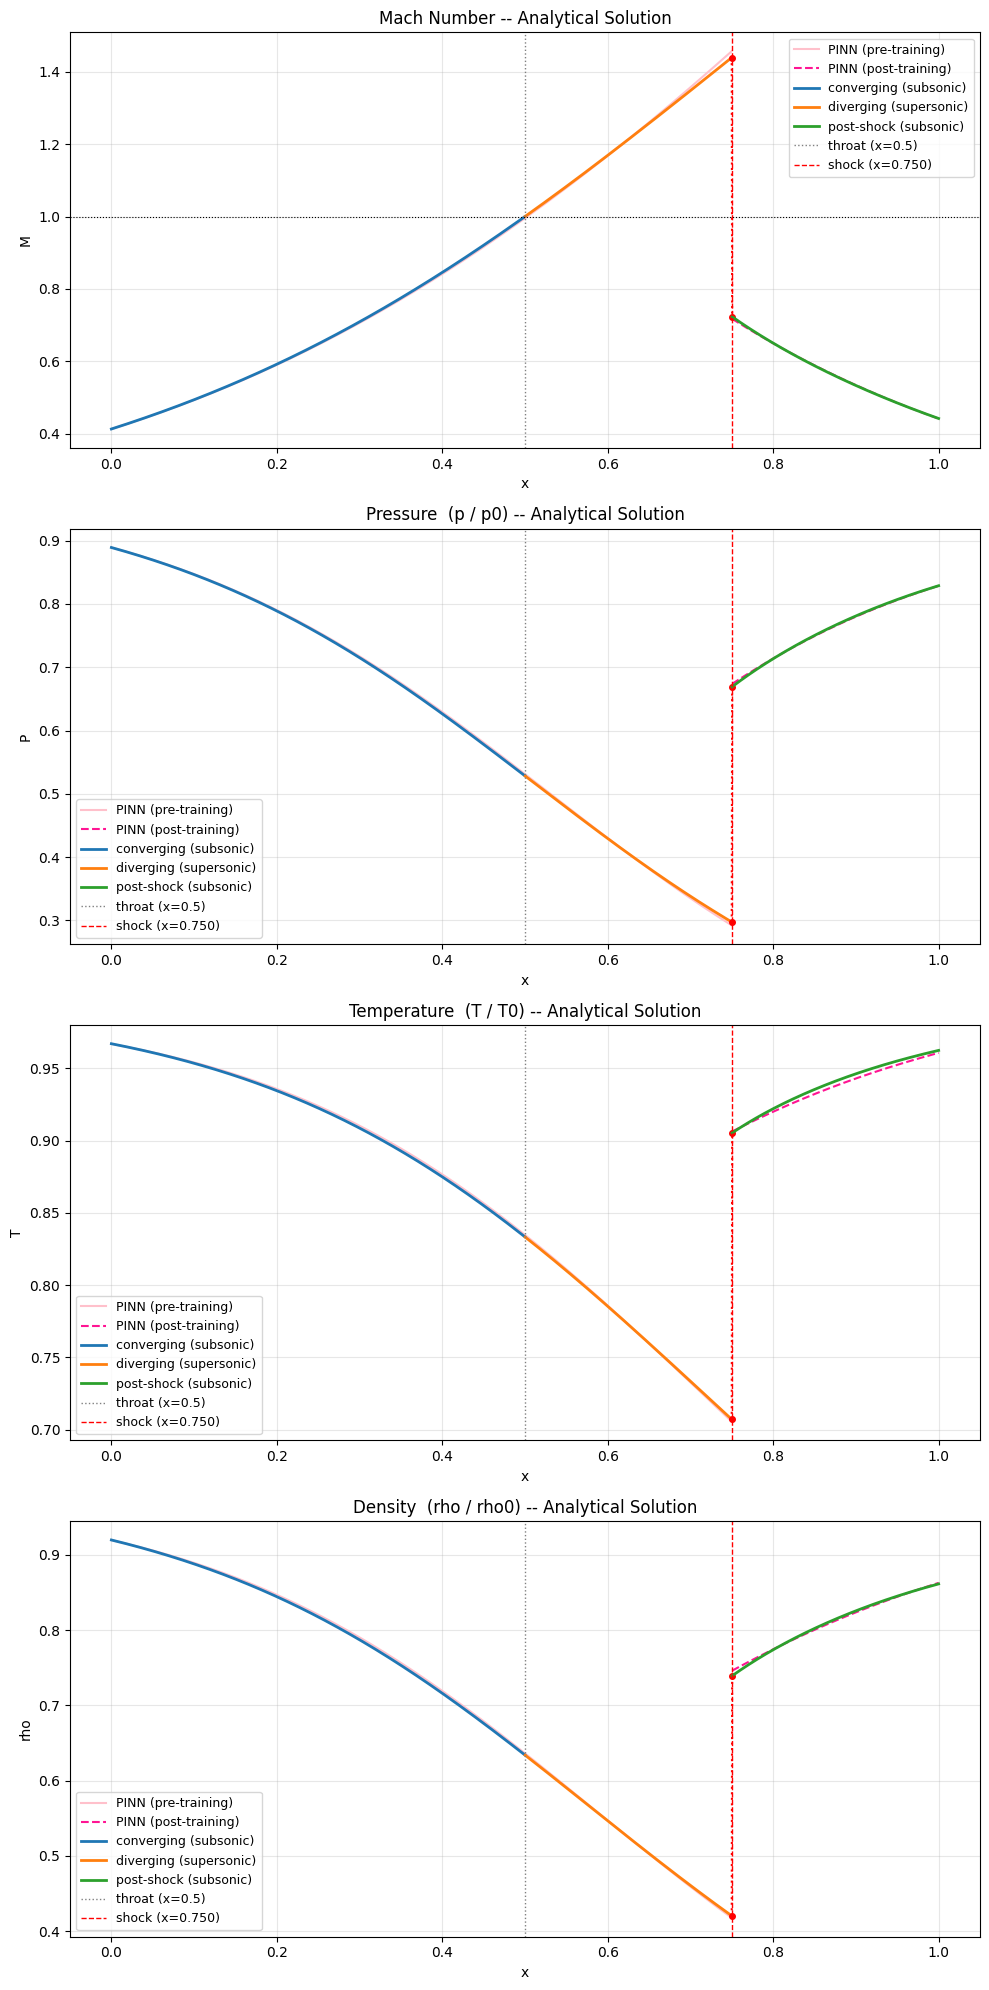

Shock at x = 0.7500
M:   1.4393 (pre-shock)  ->  0.7237 (post-shock)
P0 ratio across shock (p02/p01): 0.9478
Exit conditions: M=0.4419  P=0.8289  T=0.9624  rho=0.8613
Done.


In [14]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

x_sub, (M_sub, P_sub, T_sub, rho_sub) = analytic.data("subsonic")
x_sup, (M_sup, P_sup, T_sup, rho_sup) = analytic.data("supersonic")
x_post, (M_post, P_post, T_post, rho_post) = analytic.data("post-shock")

panels = [
    ("Mach Number", "M", (M_sub, M_sup, M_post), [pre_results[4], post_results[4]]),
    ("Pressure  (p / p0)", "P", (P_sub, P_sup, P_post), [pre_results[2], post_results[2]]),
    ("Temperature  (T / T0)", "T", (T_sub, T_sup, T_post), [pre_results[3], post_results[3]]),
    ("Density  (rho / rho0)", "rho", (rho_sub, rho_sup, rho_post), [pre_results[0], post_results[0]]),
]



for ax, (title, ylabel, analytical, pinn) in zip(axes, panels):
    pinn_pre, pinn_post = pinn
    x_pinn_pre = x_eval_np[x_eval_np < final_shock_loc]
    x_pinn_post = x_eval_np[x_eval_np >= final_shock_loc]
    ax.plot(x_pinn_pre, pinn_pre, color="pink", label="PINN (pre-training)")
    ax.plot(x_pinn_post, pinn_post, color="deeppink", ls="--", label="PINN (post-training)")

    y_sub, y_sup, y_post = analytical
    ax.plot(x_sub, y_sub, color="tab:blue", lw=2, label="converging (subsonic)")
    ax.plot(x_sup, y_sup, color="tab:orange", lw=2, label="diverging (supersonic)")
    ax.plot(
        [x_sup[-1], x_post[0]], [y_sup[-1], y_post[0]],
        color="red", lw=1.5, ls=":", marker="o", ms=4,
    )

    ax.plot(x_post, y_post, color="tab:green", lw=2, label="post-shock (subsonic)")

    ax.axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
    ax.axvline(
        analytic.x_shock, color="red", ls="--", lw=1,
        label=f"shock (x={analytic.x_shock:.3f})",
    )
    if title == "Mach Number":
        ax.axhline(1.0, color="black", ls=":", lw=0.8)

    ax.set_title(f"{title} -- Analytical Solution")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("x")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cd_nozzle_analytical_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Shock at x = {analytic.x_shock:.4f}")
print(f"M:   {analytic.M1:.4f} (pre-shock)  ->  {analytic.M2:.4f} (post-shock)")
print(f"P0 ratio across shock (p02/p01): {analytic.p02_by_p01:.4f}")
print(f"Exit conditions: M={M_post[-1]:.4f}  P={P_post[-1]:.4f}  T={T_post[-1]:.4f}  rho={rho_post[-1]:.4f}")
print("Done.")

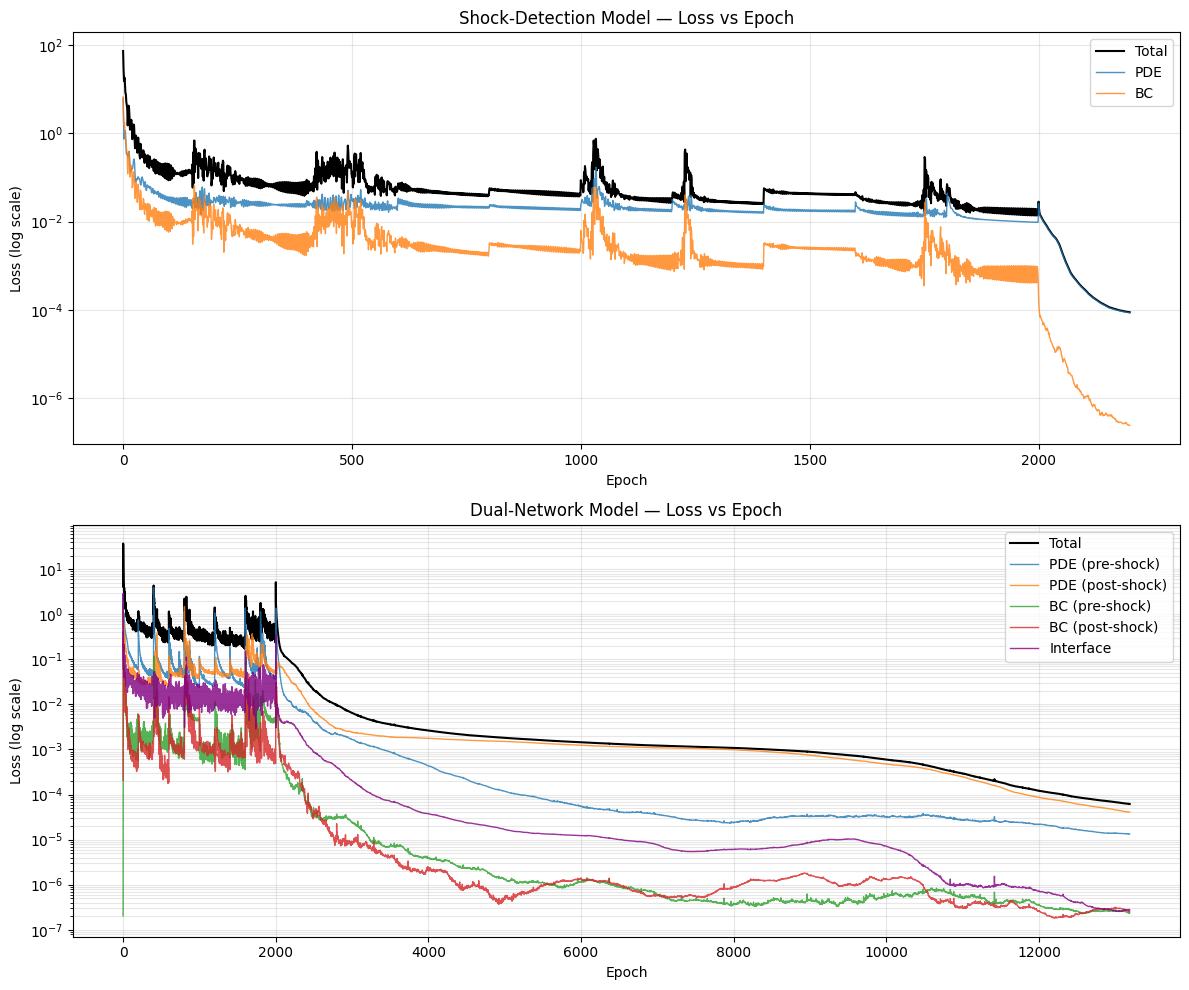

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sd = np.array(shock_det_history)
axes[0].semilogy(sd[:, 2], color="black",      lw=1.5, label="Total")
axes[0].semilogy(sd[:, 0], color="tab:blue",   lw=1,   label="PDE", alpha=0.8)
axes[0].semilogy(sd[:, 1], color="tab:orange", lw=1,   label="BC",  alpha=0.8)
axes[0].set_title("Shock-Detection Model — Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (log scale)")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

dl = np.array(dual_loss_history)
axes[1].semilogy(dl[:, 0], color="black",      lw=1.5, label="Total")
axes[1].semilogy(dl[:, 1], color="tab:blue",   lw=1,   label="PDE (pre-shock)",  alpha=0.8)
axes[1].semilogy(dl[:, 2], color="tab:orange", lw=1,   label="PDE (post-shock)", alpha=0.8)
axes[1].semilogy(dl[:, 3], color="tab:green",  lw=1,   label="BC (pre-shock)",   alpha=0.8)
axes[1].semilogy(dl[:, 4], color="tab:red",    lw=1,   label="BC (post-shock)",  alpha=0.8)
axes[1].semilogy(dl[:, 5], color="purple",     lw=1,   label="Interface",        alpha=0.8)
axes[1].set_title("Dual-Network Model — Loss vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (log scale)")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("loss_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ── New boundary condition for shock at x = 0.9 ───────────────────────────────
X_SHOCK_NEW = 0.9
P_EXIT_NEW = get_back_pressure_from_shock(X_SHOCK_NEW)
print(f"New P_EXIT = {P_EXIT_NEW:.4f}  (was {P_EXIT:.4f})")

# Monkey-patch P_EXIT globally so all loss functions pick it up
P_EXIT = P_EXIT_NEW
X_SHOCK_REF = X_SHOCK_NEW
analytic_new = AnalyticSolution()
analytic_new.x_shock = X_SHOCK_NEW
analytic_new._solve()

# ── Helper: clone weights from an existing trained model ──────────────────────
def clone_weights(src: nn.Module, dst: nn.Module):
    dst.load_state_dict(deepcopy(src.state_dict()))

# ══════════════════════════════════════════════════════════════════════════════
# VARIANT A — full retrain from scratch (new random init)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("VARIANT A: Retraining shock-detection model from scratch")
print("="*60)
shock_det_model_A = UnsteadyNet().to(device)
shock_det_history_A, _ = shock_det_train(shock_det_model_A)
x_shock_A = predict_shock_location(shock_det_model_A)

print("\nTraining dual network from scratch (Variant A)...")
pre_model_A, post_model_A, shock_param_A, dual_history_A, _ = dual_network_training_loop(x_shock_A)

# ══════════════════════════════════════════════════════════════════════════════
# VARIANT B — warm-start: copy old coarse (shock-detection) weights, retrain dual
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("VARIANT B: Warm-start from old shock-detection model weights")
print("="*60)
shock_det_model_B = UnsteadyNet().to(device)
clone_weights(shock_detection_model, shock_det_model_B)   # copy OLD coarse weights
shock_det_history_B, _ = shock_det_train(shock_det_model_B)
x_shock_B = predict_shock_location(shock_det_model_B)

print("\nTraining dual network warm-started from old coarse weights (Variant B)...")
pre_model_B, post_model_B, shock_param_B, dual_history_B, _ = dual_network_training_loop(x_shock_B)

New P_EXIT = 0.7101  (was 0.8289)

VARIANT A: Retraining shock-detection model from scratch
[shock_det_model] Adam phase (2000 epochs)
  epoch  500/2000  pde=2.6953e-02  bc=5.1694e-03  total=7.8647e-02
  epoch 1000/2000  pde=2.0628e-02  bc=5.8955e-03  total=7.9582e-02
  epoch 1500/2000  pde=1.5795e-02  bc=1.2282e-03  total=2.8077e-02
  epoch 2000/2000  pde=1.7164e-02  bc=1.2005e-03  total=2.9168e-02
[shock_det_model] L-BFGS phase (200 epochs)…
  L-BFGS 100/200  pde=2.6573e-03  bc=7.3908e-06  total=2.7312e-03
  L-BFGS 200/200  pde=4.1952e-04  bc=9.5300e-07  total=4.2905e-04
  Saved: saved_models/shock_det_model.2026-06-20_09-41-32.pt
Max M post-throat: 1.5075
Detected shock at x = 0.672336  (reference = 0.9000)

Training dual network from scratch (Variant A)...
Dual network Adam phase (2000 epochs)…
  epoch 500/2000  x_shock=0.69010  loss=8.0659e-01  pde=(9.780e-02,6.672e-02)  bc=(4.145e-03,8.069e-03)  interface=2.995e-02  M@shock: pre=1.816(>1) post=0.615(<1)
  Remesh at epoch 600: x_s

In [17]:
def dual_network_training_loop_C(label: str,
                                  init_net_L: UnsteadyNet | None = None,
                                  init_net_R: UnsteadyNet | None = None,
                                  init_shock_x: float = X_SHOCK_NEW):
    """
    Variant C  – train from scratch (init_net_L/R = None)
                 or warm-start from supplied network weights.
    Identical to dual_network_training_loop but uses X_SHOCK_NEW as prior
    centre so the shock prior pulls toward 0.9 instead of 0.75.
    """
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)

    if init_net_L is not None:
        net_L.load_state_dict(init_net_L.state_dict())
        print(f"[{label}] Loaded weights into net_L from supplied model.")
    else:
        net_L.load_state_dict(shock_detection_model.state_dict())
        print(f"[{label}] Initialised net_L from shock-detection model.")

    if init_net_R is not None:
        net_R.load_state_dict(init_net_R.state_dict())
        print(f"[{label}] Loaded weights into net_R from supplied model.")
    else:
        net_R.load_state_dict(shock_detection_model.state_dict())
        print(f"[{label}] Initialised net_R from shock-detection model.")

    shock = ShockParam(init_shock_x).to(device)
    last_x_shock = init_shock_x

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam phase ────────────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"[{label}] Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
                print(f"  [{label}] Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}")

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_NEW) ** 2          # <-- new prior centre

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()
        bc_L  = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R  = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L: net_L.load_state_dict(snap_L)
            if snap_R: net_R.load_state_dict(snap_R)
            if snap_I: shock.load_state_dict(snap_I)
            print(f"  [{label}] NaN at epoch {epoch} — restored best snapshot, continuing")
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_NEW) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append((
            loss.item(), pde_L.item(), pde_R.item(),
            bc_L.item(), bc_R.item(), interface.item(),
            shock.clamped_x().item(),
        ))
        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L, o_R = net_L(xt_s), net_R(xt_s)
                M_L = (o_L[0,1] / torch.sqrt(GAMMA * o_L[0,2] / o_L[0,0])).item()
                M_R = (o_R[0,1] / torch.sqrt(GAMMA * o_R[0,2] / o_R[0,0])).item()
            print(
                f"  [{label}] epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS phase ─────────────────────────────────────────────────────────
    print(f"[{label}] L-BFGS phase ({DUAL_NET_LBFGS_EPOCHS} epochs)…")
    pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
    t_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
    last = {}

    lbfgs = torch.optim.LBFGS(
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters()),
        line_search_fn="strong_wolfe",
    )

    def closure_dual():
        lbfgs.zero_grad()
        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()
        bc_L  = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
        bc_R  = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_lbfgs)
        prior = (shock.clamped_x() - X_SHOCK_NEW) ** 2          # <-- new prior centre

        loss = (
            pde_L + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )
        loss.backward()
        loss_data = (
            loss.item(), pde_L.item(), pde_R.item(),
            bc_L.item(), bc_R.item(), interface.item(),
            shock.clamped_x().item(),
        )

        loss_history.append(loss_data)
        last["loss"] = loss_data
        return loss

    for epoch in range(DUAL_NET_LBFGS_EPOCHS):
        lbfgs.step(closure_dual)
        best_L, snap_L = ModelHandler.update_best(net_L, last["loss"][0], best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, last["loss"][0], best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, last["loss"][0], best_I, snap_I)

        if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L, o_R = net_L(xt_s), net_R(xt_s)
                M_L = (o_L[0,1] / torch.sqrt(GAMMA * o_L[0,2] / o_L[0,0])).item()
                M_R = (o_R[0,1] / torch.sqrt(GAMMA * o_R[0,2] / o_R[0,0])).item()
            print(
                f"  [{label}] L-BFGS {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={last['loss'][0]:.4e}  "
                f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "
                f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "
                f"interface={last['loss'][5]:.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    suffix = label.lower().replace(" ", "_")
    path_L = ModelHandler.save_path(f"dual_net_pre_{suffix}")
    path_R = ModelHandler.save_path(f"dual_net_post_{suffix}")
    path_I = ModelHandler.save_path(f"interface_{suffix}")
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return net_L, net_R, shock, loss_history, (path_L, path_R, path_I)


# ── Variant C: train completely from scratch with new P_EXIT ───────────────────
print("=" * 60)
print("VARIANT C — from scratch, x_shock prior → 0.9")
print("=" * 60)
(pre_C, post_C, shock_C, loss_history_C, paths_C) = dual_network_training_loop_C(
    label="Variant C",
    init_net_L=shock_detection_model,   # copy weights from original trained coarse network
    init_net_R=shock_detection_model,   # copy weights from original trained coarse network
    init_shock_x=x_shock
)

# ── Variant D: warm-start from the original trained dual networks ──────────────
print("=" * 60)
print("VARIANT D — warm-start from original trained dual nets, x_shock prior → 0.9")
print("=" * 60)
(pre_D, post_D, shock_D, loss_history_D, paths_D) = dual_network_training_loop_C(
    label="Variant D",
    init_net_L=pre_shock_model,   # copy weights from original trained net_L
    init_net_R=post_shock_model,  # copy weights from original trained net_R
    init_shock_x=shock_param.clamped_x().item(),  # start shock from where it converged
)

VARIANT C — from scratch, x_shock prior → 0.9
[Variant C] Loaded weights into net_L from supplied model.
[Variant C] Loaded weights into net_R from supplied model.
[Variant C] Adam phase (2000 epochs)…
  [Variant C] epoch 500/2000  x_shock=0.62388  loss=6.7164e-01  pde=(4.757e-02,4.608e-02)  bc=(9.850e-04,7.388e-04)  interface=1.793e-02  M@shock: pre=1.562(>1) post=0.748(<1)
  [Variant C] Remesh at epoch 600: x_shock = 0.633145
  [Variant C] epoch 1000/2000  x_shock=0.66826  loss=5.2384e-01  pde=(3.332e-02,3.576e-02)  bc=(4.152e-04,5.190e-04)  interface=1.767e-02  M@shock: pre=1.645(>1) post=0.670(<1)
  [Variant C] Remesh at epoch 1200: x_shock = 0.684862
  [Variant C] epoch 1500/2000  x_shock=0.70702  loss=3.8864e-01  pde=(4.927e-02,4.491e-02)  bc=(6.720e-04,2.725e-03)  interface=7.414e-03  M@shock: pre=1.838(>1) post=0.616(<1)
  [Variant C] Remesh at epoch 1800: x_shock = 0.728477
  [Variant C] epoch 2000/2000  x_shock=0.74225  loss=3.8198e-01  pde=(3.582e-02,4.698e-02)  bc=(9.948e-0

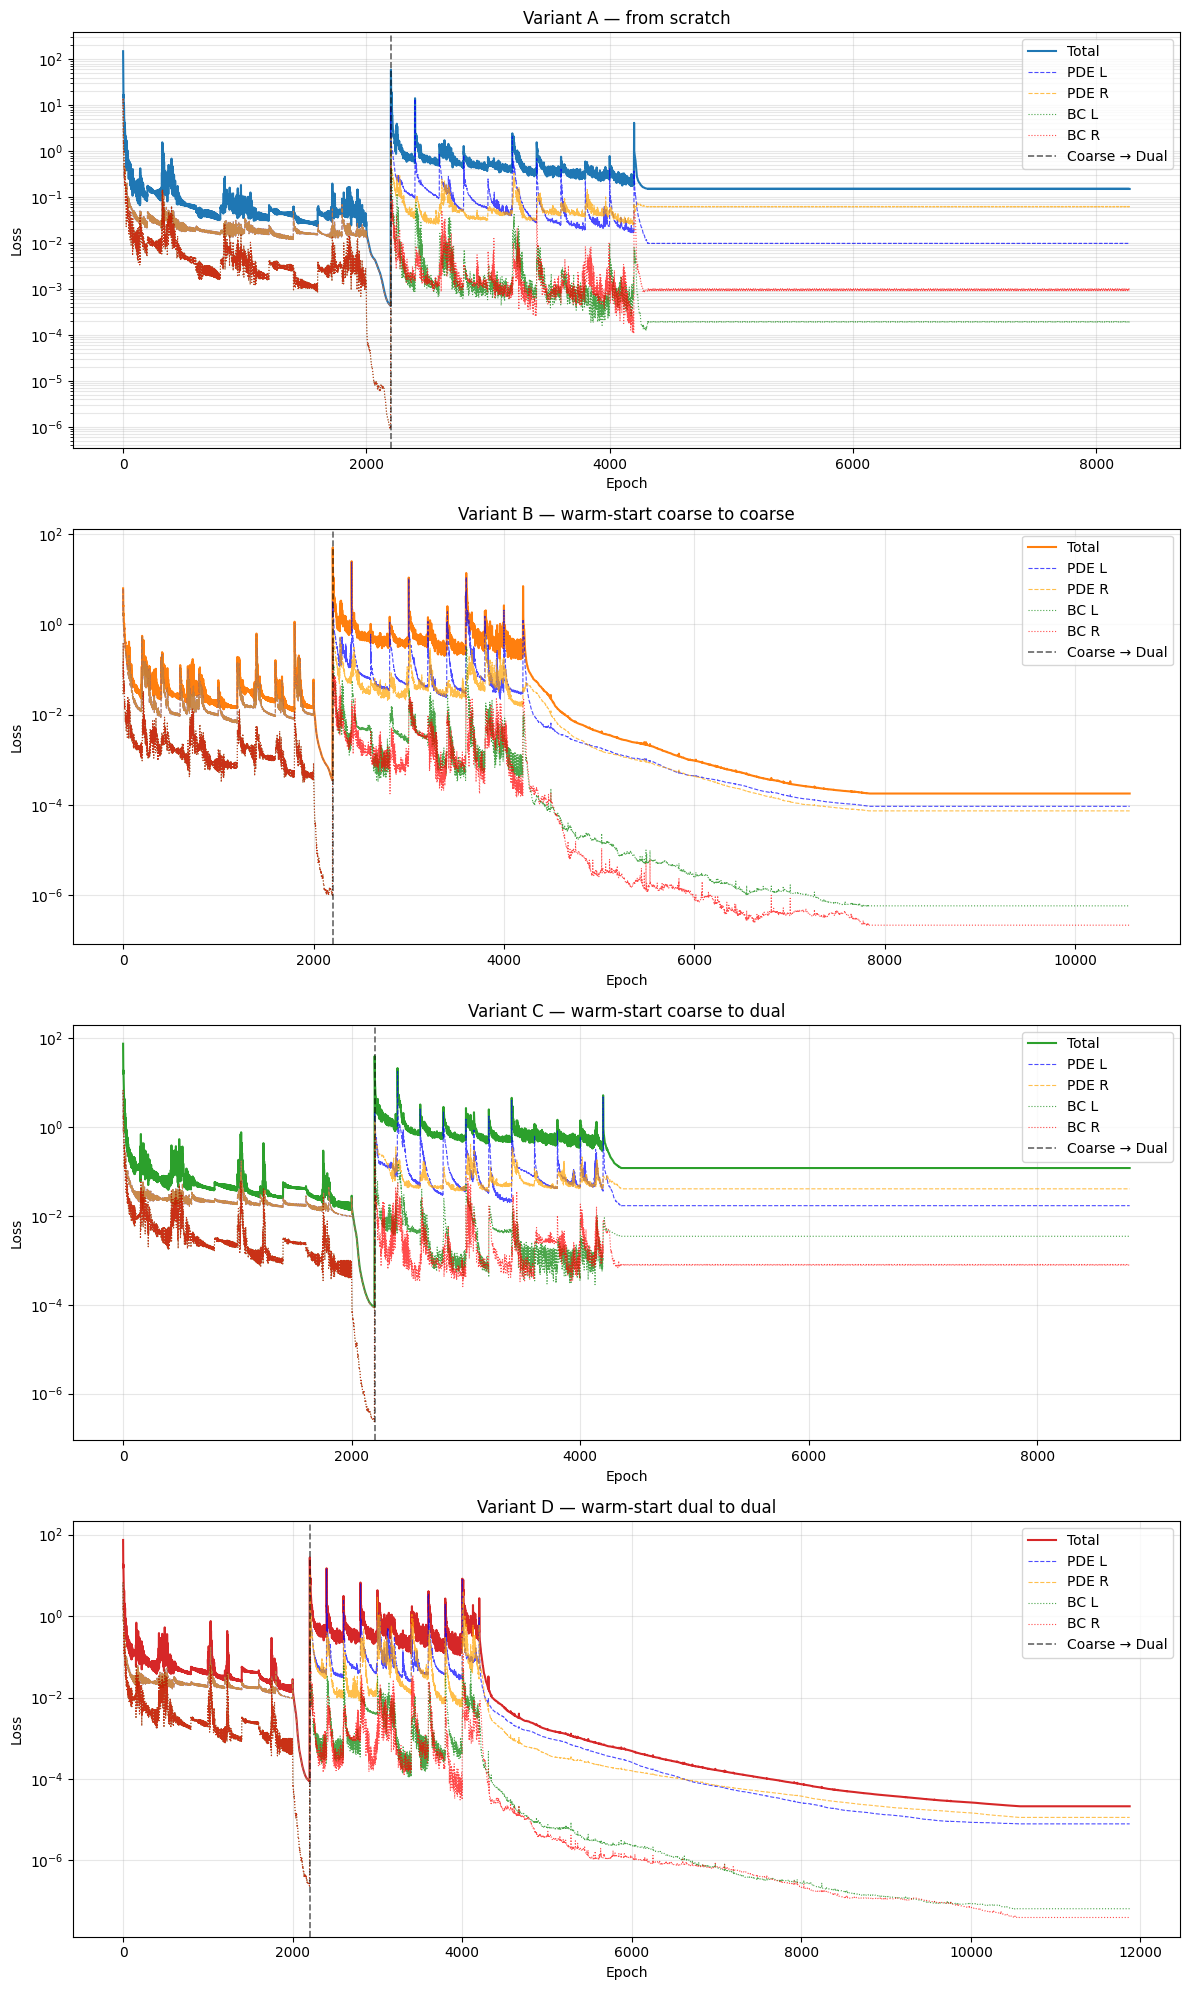

In [18]:
def combine_coarse_and_dual(coarse_hist, dual_hist):
    """
    coarse_hist: list of (pde, bc, total)  → we want total as col 0, pad others with NaN
    dual_hist:   list of (total, pde_L, pde_R, bc_L, bc_R, interface, x_shock)
    Returns a single array with columns matching dual_hist format, and the split index.
    """
    coarse = np.array(coarse_hist)   # shape (N, 3): pde, bc, total
    dual   = np.array(dual_hist)     # shape (M, 7)

    # Build coarse rows in dual format: [total, pde≈col0, pde≈col0, bc≈col1, bc≈col1, NaN, NaN]
    coarse_padded = np.full((len(coarse), dual.shape[1]), np.nan)
    coarse_padded[:, 0] = coarse[:, 2]   # total
    coarse_padded[:, 1] = coarse[:, 0]   # pde → PDE L slot
    coarse_padded[:, 2] = coarse[:, 0]   # pde → PDE R slot (same, single net)
    coarse_padded[:, 3] = coarse[:, 1]   # bc  → BC L slot
    coarse_padded[:, 4] = coarse[:, 1]   # bc  → BC R slot (same, single net)

    combined = np.concatenate([coarse_padded, dual], axis=0)
    return combined, len(coarse)


def plot_configs(configs, ax_slice):
    for ax, (coarse_hist, dual_hist, label, color) in zip(ax_slice, configs):
        dl, split_at = combine_coarse_and_dual(coarse_hist, dual_hist)
        epochs = np.arange(len(dl))
        ax.semilogy(epochs, dl[:, 0], color=color,    lw=1.5,           label="Total")
        ax.semilogy(epochs, dl[:, 1], color="blue",   lw=0.8, ls="--", alpha=0.7, label="PDE L")
        ax.semilogy(epochs, dl[:, 2], color="orange", lw=0.8, ls="--", alpha=0.7, label="PDE R")
        ax.semilogy(epochs, dl[:, 3], color="green",  lw=0.8, ls=":",  alpha=0.7, label="BC L")
        ax.semilogy(epochs, dl[:, 4], color="red",    lw=0.8, ls=":",  alpha=0.7, label="BC R")
        ax.axvline(split_at, color="black", lw=1.2, ls="--", alpha=0.6, label="Coarse → Dual")
        ax.set_title(label); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(); ax.grid(True, which="both", alpha=0.3)

fig, axes = plt.subplots(4, 1, figsize=(12, 20))

configs_1 = [
    (shock_det_history_A, dual_history_A, "Variant A — from scratch",                "tab:blue"),
    (shock_det_history_B, dual_history_B, "Variant B — warm-start coarse to coarse", "tab:orange"),
]
configs_2 = [
    (shock_det_history, loss_history_C, "Variant C — warm-start coarse to dual",   "tab:green"),
    (shock_det_history, loss_history_D, "Variant D — warm-start dual to dual",     "tab:red"),
]

plot_configs(configs_1, axes[:2])
plot_configs(configs_2, axes[2:])

plt.tight_layout()
plt.show()

In [ ]:
import math
import time

class LoRALinear(nn.Module):
    def __init__(self, base_linear: nn.Linear, rank: int, alpha: float | None = None):
        super().__init__()
        self.in_features = base_linear.in_features
        self.out_features = base_linear.out_features
        self.rank = rank
        self.alpha = float(alpha) if alpha is not None else float(rank)
        self.scaling = self.alpha / self.rank if rank > 0 else 0.0

        self.weight = nn.Parameter(base_linear.weight.data.clone(), requires_grad=False)
        if base_linear.bias is not None:
            self.bias = nn.Parameter(base_linear.bias.data.clone(), requires_grad=False)
        else:
            self.bias = None

        if rank > 0:
            self.lora_A = nn.Parameter(torch.zeros(rank, self.in_features))
            self.lora_B = nn.Parameter(torch.zeros(self.out_features, rank))
            nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
            nn.init.zeros_(self.lora_B)
        else:
            self.register_parameter("lora_A", None)
            self.register_parameter("lora_B", None)

        self.merged = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = nn.functional.linear(x, self.weight, self.bias)
        if self.rank > 0 and not self.merged:
            out = out + self.scaling * nn.functional.linear(
                nn.functional.linear(x, self.lora_A), self.lora_B
            )
        return out

    @torch.no_grad()
    def merge(self):
        """Fold the current adapter into the frozen base weight (in place)."""
        if self.rank > 0 and not self.merged:
            self.weight.add_(self.scaling * (self.lora_B @ self.lora_A))
            self.merged = True

    @torch.no_grad()
    def unmerge(self):
        """Undo `merge()` — restores the separate base / adapter split."""
        if self.rank > 0 and self.merged:
            self.weight.sub_(self.scaling * (self.lora_B @ self.lora_A))
            self.merged = False

    def extra_repr(self) -> str:
        return f"in={self.in_features}, out={self.out_features}, rank={self.rank}, alpha={self.alpha}"


def apply_lora(model: "UnsteadyNet", rank: int, alpha: float | None = None) -> "UnsteadyNet":
    """In-place: replace every nn.Linear inside `model.net` with a LoRALinear
    of the given rank. All other layers (Tanh) pass through unchanged."""
    new_layers = []
    for layer in model.net:
        if isinstance(layer, nn.Linear):
            new_layers.append(LoRALinear(layer, rank=rank, alpha=alpha))
        else:
            new_layers.append(layer)
    model.net = nn.Sequential(*new_layers)
    return model


def lora_parameters(model: nn.Module) -> list[nn.Parameter]:
    """Only the trainable LoRA A/B matrices of a LoRA-wrapped model."""
    params = []
    for m in model.modules():
        if isinstance(m, LoRALinear) and m.rank > 0:
            params.append(m.lora_A)
            params.append(m.lora_B)
    return params


def count_parameters(model: nn.Module) -> tuple[int, int]:
    """(trainable, total) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


@torch.no_grad()
def merge_all_lora(model: nn.Module) -> nn.Module:
    """Fold every LoRA adapter in `model` into its frozen base weight."""
    for m in model.modules():
        if isinstance(m, LoRALinear):
            m.merge()
    return model


def lora_state_dict(model: nn.Module) -> dict:
    """Just the adapter weights — a tiny checkpoint to ship instead of the full model."""
    return {n: p.detach().cpu().clone() for n, p in model.named_parameters() if "lora_" in n}


def lora_model_to_plain(model: nn.Module, merge: bool = True) -> "UnsteadyNet":
    """
    Collapse a (possibly LoRA-wrapped) model into a plain UnsteadyNet
    (ordinary nn.Linear layers, no adapter) holding its effective weights.
    If merge=True, any live adapters are folded in first.
    """
    if merge:
        merge_all_lora(model)
    plain = UnsteadyNet().to(device)
    base_state = {n: p.detach().clone() for n, p in model.named_parameters() if "lora_" not in n}
    plain.load_state_dict(base_state, strict=True)
    return plain


def make_lora_model(source: nn.Module, rank: int, alpha: float | None = None) -> "UnsteadyNet":
    """
    Build a *new* UnsteadyNet, copy `source`'s effective weights into it as a
    frozen base (merging first if `source` is itself LoRA-wrapped), and wrap
    every Linear layer with a fresh rank-`r` adapter (B=0 ⇒ exact warm start).
    """
    is_lora_wrapped = any(isinstance(m, LoRALinear) for m in source.modules())
    base = lora_model_to_plain(source, merge=True) if is_lora_wrapped else source
    target = UnsteadyNet().to(device)
    target.load_state_dict(deepcopy(base.state_dict()))
    apply_lora(target, rank=rank, alpha=alpha)
    return target.to(device)


print("LoRA core (LoRALinear, apply_lora, make_lora_model, merge/clone utilities) defined.")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LoRA fine-tuning loops — identical physics/losses to the full fine-tune
# versions above, but the optimizer only ever touches LoRA A/B matrices
# (+ the scalar shock location). Base weights stay frozen throughout.
# ══════════════════════════════════════════════════════════════════════════════
def lora_coarse_train(
    model: UnsteadyNet,
    label: str,
    adam_epochs: int,
    lbfgs_epochs: int = 0,
    verbose: bool = True,
) -> tuple[UnsteadyNet, list[tuple[float, float, float]]]:
    """LoRA fine-tune of a single (coarse / shock-detection) UnsteadyNet."""
    params = lora_parameters(model)
    if not params:
        raise ValueError("rank=0 LoRA model has no trainable adapter parameters.")

    history, best_loss, best_snap = [], float("inf"), ModelHandler.snapshot(model)
    optimizer = torch.optim.Adam(params, lr=SHOCK_DET_ADAM_LR)
    xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)

    if verbose:
        print(f"[{label}] LoRA Adam phase ({adam_epochs} epochs)")
    for epoch in range(adam_epochs):
        if epoch % SHOCK_DET_RESAMPLE_EVERY == 0:
            xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)

        optimizer.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt)
        loss.backward()
        nn.utils.clip_grad_norm_(params, SHOCK_DET_GRAD_CLIP)
        optimizer.step()

        best_loss, best_snap = ModelHandler.update_best(
            model, loss.item(), best_loss, best_snap
        )
        history.append((pde_loss.item(), bc_loss.item(), loss.item()))

        if verbose and (epoch + 1) % SHOCK_DET_PRINT_EVERY == 0:
            print(
                f"  [{label}] epoch {epoch+1}/{adam_epochs}  "
                f"pde={pde_loss.item():.4e}  bc={bc_loss.item():.4e}  total={loss.item():.4e}"
            )

    model.load_state_dict(best_snap)

    if lbfgs_epochs > 0:
        if verbose:
            print(f"[{label}] LoRA L-BFGS phase ({lbfgs_epochs} epochs)…")
        xt_lbfgs = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
        lbfgs = torch.optim.LBFGS(params, line_search_fn="strong_wolfe")
        last = {}

        def closure():
            lbfgs.zero_grad()
            loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt_lbfgs)
            loss.backward()
            last["loss"], last["pde"], last["bc"] = (
                loss.item(),
                pde_loss.item(),
                bc_loss.item(),
            )
            history.append((pde_loss.item(), bc_loss.item(), loss.item()))
            return loss

        for epoch in range(lbfgs_epochs):
            lbfgs.step(closure)
            best_loss, best_snap = ModelHandler.update_best(
                model, last["loss"], best_loss, best_snap
            )
            history.append((last["pde"], last["bc"], last["loss"]))
            if verbose and (epoch + 1) % max(1, lbfgs_epochs // 5) == 0:
                print(
                    f"  [{label}] L-BFGS {epoch+1}/{lbfgs_epochs}  total={last['loss']:.4e}"
                )

    model.load_state_dict(best_snap)
    return model, history


def lora_dual_train(
    net_L: UnsteadyNet,
    net_R: UnsteadyNet,
    shock: ShockParam,
    label: str,
    last_x_shock: float,
    prior_center: float,
    adam_epochs: int,
    lbfgs_epochs: int = 0,
    verbose: bool = True,
) -> tuple[UnsteadyNet, UnsteadyNet, ShockParam, list[tuple]]:
    """LoRA fine-tune of an already warm-started dual network pair."""
    params = lora_parameters(net_L) + lora_parameters(net_R)
    if not params:
        raise ValueError("rank=0 LoRA model has no trainable adapter parameters.")

    model_opt = torch.optim.Adam(params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), ModelHandler.snapshot(net_L)
    best_R, snap_R = float("inf"), ModelHandler.snapshot(net_R)
    best_I, snap_I = float("inf"), ModelHandler.snapshot(shock)
    loss_history = []

    if verbose:
        print(f"[{label}] LoRA Adam phase ({adam_epochs} epochs)…")

    for epoch in range(adam_epochs):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(
                    last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS
                )
                if verbose:
                    print(
                        f"  [{label}] Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}"
                    )

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - prior_center) ** 2

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()
        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L:
                net_L.load_state_dict(snap_L)
            if snap_R:
                net_R.load_state_dict(snap_R)
            if snap_I:
                shock.load_state_dict(snap_I)
            if verbose:
                print(
                    f"  [{label}] NaN at epoch {epoch} — restored best snapshot, continuing"
                )
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - prior_center) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append(
            (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
        )
        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if verbose and (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            print(
                f"  [{label}] epoch {epoch+1}/{adam_epochs}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  interface={interface.item():.3e}"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    if lbfgs_epochs > 0:
        if verbose:
            print(f"[{label}] LoRA L-BFGS phase ({lbfgs_epochs} epochs)…")
        pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
        pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
        t_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        last = {}

        lbfgs = torch.optim.LBFGS(
            params + list(shock.parameters()), line_search_fn="strong_wolfe"
        )

        def closure_dual():
            lbfgs.zero_grad()
            pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
            pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()
            bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
            bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)
            interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_lbfgs)
            prior = (shock.clamped_x() - prior_center) ** 2

            loss = (
                pde_L
                + pde_R
                + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
                + DUAL_NET_INTERFACE_WEIGHT * interface
                + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
            )
            loss.backward()
            loss_data = (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
            loss_history.append(loss_data)
            last["loss"] = loss_data
            return loss

        for epoch in range(lbfgs_epochs):
            lbfgs.step(closure_dual)
            best_L, snap_L = ModelHandler.update_best(
                net_L, last["loss"][0], best_L, snap_L
            )
            best_R, snap_R = ModelHandler.update_best(
                net_R, last["loss"][0], best_R, snap_R
            )
            best_I, snap_I = ModelHandler.update_best(
                shock, last["loss"][0], best_I, snap_I
            )
            if verbose and (epoch + 1) % max(1, lbfgs_epochs // 5) == 0:
                print(
                    f"  [{label}] L-BFGS {epoch+1}/{lbfgs_epochs}  loss={last['loss'][0]:.4e}"
                )

        net_L.load_state_dict(snap_L)
        net_R.load_state_dict(snap_R)
        shock.load_state_dict(snap_I)

    return net_L, net_R, shock, loss_history


print("LoRA training loops (lora_coarse_train, lora_dual_train) defined.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Variant-specific warm starts, reproduced exactly but via LoRA adapters
# ══════════════════════════════════════════════════════════════════════════════
def build_variant_models(
    variant: str,
    rank: int,
    alpha: float | None = None,
    adam_epochs: int = 0,
    lbfgs_epochs: int = 0,
):
    """
    Returns (net_L, net_R, shock, last_x_shock, prior_center) for one LoRA
    variant, mirroring the full fine-tune Variants B / C / D defined earlier:

      B — warm-start COARSE -> (re-detect shock) -> COARSE -> DUAL
      C — warm-start COARSE -> DUAL directly
      D — warm-start DUAL   -> DUAL directly
    """
    variant = variant.upper()

    if variant == "B":
        coarse = make_lora_model(shock_detection_model, rank=rank, alpha=alpha)
        coarse, _ = lora_coarse_train(
            coarse, label=f"B-coarse-r{rank}",
            adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, verbose=False,
        )
        x_shock_b = predict_shock_location(coarse)
        net_L = make_lora_model(coarse, rank=rank, alpha=alpha)
        net_R = make_lora_model(coarse, rank=rank, alpha=alpha)
        shock = ShockParam(x_shock_b).to(device)
        last_x_shock = x_shock_b

    elif variant == "C":
        net_L = make_lora_model(shock_detection_model, rank=rank, alpha=alpha)
        net_R = make_lora_model(shock_detection_model, rank=rank, alpha=alpha)
        shock = ShockParam(x_shock).to(device)
        last_x_shock = x_shock

    elif variant == "D":
        x0 = shock_param.clamped_x().item()
        net_L = make_lora_model(pre_shock_model, rank=rank, alpha=alpha)
        net_R = make_lora_model(post_shock_model, rank=rank, alpha=alpha)
        shock = ShockParam(x0).to(device)
        last_x_shock = x0

    else:
        raise ValueError(f"Unknown variant {variant!r}; expected 'B', 'C', or 'D'.")

    return net_L, net_R, shock, last_x_shock, X_SHOCK_NEW


def lora_finetune_variant(
    variant: str,
    rank: int,
    alpha: float | None = None,
    adam_epochs: int = 400,
    lbfgs_epochs: int = 0,
    verbose: bool = False,
) -> dict:
    """Build + LoRA fine-tune one (variant, rank) configuration end to end."""
    t0 = time.time()
    net_L, net_R, shock, last_x_shock, prior_center = build_variant_models(
        variant, rank, alpha, adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs,
    )

    trainable_L, total_L = count_parameters(net_L)
    trainable_R, total_R = count_parameters(net_R)

    net_L, net_R, shock, loss_history = lora_dual_train(
        net_L, net_R, shock,
        label=f"{variant}-dual-r{rank}",
        last_x_shock=last_x_shock,
        prior_center=prior_center,
        adam_epochs=adam_epochs,
        lbfgs_epochs=lbfgs_epochs,
        verbose=verbose,
    )
    elapsed = time.time() - t0

    final_loss = loss_history[-1][0] if loss_history else float("nan")
    final_x_shock = shock.clamped_x().item()

    return {
        "variant": variant,
        "rank": rank,
        "alpha": alpha if alpha is not None else float(rank),
        "net_L": net_L, "net_R": net_R, "shock": shock,
        "loss_history": loss_history,
        "trainable_params": trainable_L + trainable_R,
        "total_params": total_L + total_R,
        "final_loss": final_loss,
        "final_x_shock": final_x_shock,
        "x_shock_error": abs(final_x_shock - X_SHOCK_NEW),
        "wall_time_s": elapsed,
    }


print("build_variant_models / lora_finetune_variant defined.")


### Rank sweep

For each variant (B, C, D) and each rank `r ∈ {1, 2, 4, 8, 16, 32, 64}`, we run a
shortened LoRA fine-tune (`LORA_SWEEP_ADAM_EPOCHS` Adam steps, no L-BFGS) and record:

- trainable vs. total parameter count,
- final training loss,
- recovered shock location and its error against the new target `X_SHOCK_NEW`,
- wall-clock time.

This is cheap because LoRA only ever updates `O(r · hidden_dim)` parameters per
layer instead of the full `O(hidden_dim²)`, so the sweep can afford to try every
rank before committing to a full-budget run.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Rank sweep — variants B, C, D × ranks {1,2,4,8,16,32,64}
# ══════════════════════════════════════════════════════════════════════════════
LORA_RANKS = [1, 2, 4, 8, 16, 32, 64]
LORA_VARIANTS = ["B", "C", "D"]

# Shortened budget for the sweep itself (cheap, since only LoRA params train).
LORA_SWEEP_ADAM_EPOCHS = 400
LORA_SWEEP_LBFGS_EPOCHS = 0

# Full budget used later for the final, chosen-rank production run per variant.
LORA_FINAL_ADAM_EPOCHS = DUAL_NET_ADAM_EPOCHS
LORA_FINAL_LBFGS_EPOCHS = DUAL_NET_LBFGS_EPOCHS

lora_sweep_results = []
for _variant in LORA_VARIANTS:
    for _rank in LORA_RANKS:
        print(f"\n--- LoRA sweep: variant {_variant}, rank {_rank} ---")
        _res = lora_finetune_variant(
            _variant, _rank,
            adam_epochs=LORA_SWEEP_ADAM_EPOCHS,
            lbfgs_epochs=LORA_SWEEP_LBFGS_EPOCHS,
            verbose=False,
        )
        lora_sweep_results.append(_res)
        print(
            f"  trainable={_res['trainable_params']:>6d}/{_res['total_params']:<6d} "
            f"({100*_res['trainable_params']/_res['total_params']:.2f}%)  "
            f"final_loss={_res['final_loss']:.4e}  x_shock={_res['final_x_shock']:.4f}  "
            f"err={_res['x_shock_error']:.4e}  time={_res['wall_time_s']:.1f}s"
        )

lora_sweep_df = pd.DataFrame([
    {
        "variant": r["variant"],
        "rank": r["rank"],
        "trainable_params": r["trainable_params"],
        "total_params": r["total_params"],
        "param_pct": 100.0 * r["trainable_params"] / r["total_params"],
        "final_loss": r["final_loss"],
        "final_x_shock": r["final_x_shock"],
        "x_shock_error": r["x_shock_error"],
        "wall_time_s": r["wall_time_s"],
    }
    for r in lora_sweep_results
]).sort_values(["variant", "rank"]).reset_index(drop=True)

print("\n" + "=" * 70)
print("LoRA rank sweep — summary")
print("=" * 70)
print(lora_sweep_df.to_string(index=False))


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Optimize: pick the most parameter-efficient rank per variant
# ══════════════════════════════════════════════════════════════════════════════
def select_best_rank(df: pd.DataFrame, loss_tol: float = 1.10) -> pd.DataFrame:
    """
    For each variant, choose the SMALLEST rank whose final loss is within
    `loss_tol`x the best (minimum) loss achieved by ANY rank for that
    variant. This favours parameter-efficient adapters that are "good
    enough" over whichever single rank happened to score the lowest loss.
    """
    picks = []
    for _variant, sub in df.groupby("variant"):
        best_loss = sub["final_loss"].min()
        ok = sub[sub["final_loss"] <= best_loss * loss_tol]
        picks.append(ok.loc[ok["rank"].idxmin()])
    return pd.DataFrame(picks).reset_index(drop=True)


LORA_LOSS_TOL = 1.10  # accept up to 10% worse loss than the sweep's best, for a smaller rank
lora_best_ranks = select_best_rank(lora_sweep_df, loss_tol=LORA_LOSS_TOL)

print("Selected (parameter-efficient) rank per variant:")
print(lora_best_ranks.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# Final, full-budget LoRA fine-tune at the selected rank for each variant
# ══════════════════════════════════════════════════════════════════════════════
lora_final_models = {}
for _, row in lora_best_ranks.iterrows():
    _variant, _rank = row["variant"], int(row["rank"])
    print(f"\n{'='*60}\nFinal LoRA fine-tune — Variant {_variant}, rank {_rank}\n{'='*60}")

    _res = lora_finetune_variant(
        _variant, _rank,
        adam_epochs=LORA_FINAL_ADAM_EPOCHS,
        lbfgs_epochs=LORA_FINAL_LBFGS_EPOCHS,
        verbose=True,
    )
    lora_final_models[_variant] = _res

    suffix = f"lora_variant_{_variant.lower()}_r{_rank}"

    # save the LoRA-wrapped checkpoints (base + adapter)
    ModelHandler.save(_res["net_L"], ModelHandler.save_path(f"{suffix}_preL"))
    ModelHandler.save(_res["net_R"], ModelHandler.save_path(f"{suffix}_postR"))
    ModelHandler.save(_res["shock"], ModelHandler.save_path(f"{suffix}_shock"))

    # also save a merged, plain (LoRA-free) checkpoint — handy for deployment
    plain_L = lora_model_to_plain(_res["net_L"], merge=True)
    plain_R = lora_model_to_plain(_res["net_R"], merge=True)
    ModelHandler.save(plain_L, ModelHandler.save_path(f"{suffix}_preL_merged"))
    ModelHandler.save(plain_R, ModelHandler.save_path(f"{suffix}_postR_merged"))

    print(
        f"  Variant {_variant} (r={_rank}): trainable={_res['trainable_params']}/"
        f"{_res['total_params']} params  final_loss={_res['final_loss']:.4e}  "
        f"x_shock={_res['final_x_shock']:.4f}  err={_res['x_shock_error']:.4e}"
    )

print("\nDone — lora_final_models holds the production model for each of B, C, D.")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Plots: rank sweep curves + LoRA vs. full fine-tune comparison
# ══════════════════════════════════════════════════════════════════════════════
_variant_colors = {"B": "tab:orange", "C": "tab:green", "D": "tab:red"}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (a) final loss vs rank
ax = axes[0, 0]
for _variant, sub in lora_sweep_df.groupby("variant"):
    ax.loglog(sub["rank"], sub["final_loss"], marker="o", color=_variant_colors[_variant],
               label=f"Variant {_variant}")
ax.set_xlabel("LoRA rank r"); ax.set_ylabel("final training loss")
ax.set_title("Loss vs LoRA rank"); ax.legend(); ax.grid(True, which="both", alpha=0.3)

# (b) trainable parameter count vs rank
ax = axes[0, 1]
for _variant, sub in lora_sweep_df.groupby("variant"):
    ax.loglog(sub["rank"], sub["trainable_params"], marker="o", color=_variant_colors[_variant],
               label=f"Variant {_variant}")
ax.set_xlabel("LoRA rank r"); ax.set_ylabel("trainable parameters")
ax.set_title("Trainable parameter count vs LoRA rank"); ax.legend(); ax.grid(True, which="both", alpha=0.3)

# (c) shock-location error vs rank
ax = axes[1, 0]
for _variant, sub in lora_sweep_df.groupby("variant"):
    ax.semilogx(sub["rank"], sub["x_shock_error"], marker="o", color=_variant_colors[_variant],
                label=f"Variant {_variant}")
for _, row in lora_best_ranks.iterrows():
    ax.axvline(row["rank"], color=_variant_colors[row["variant"]], ls=":", alpha=0.5)
ax.set_xlabel("LoRA rank r"); ax.set_ylabel(f"|x_shock - {X_SHOCK_NEW}|")
ax.set_title("Shock-location error vs LoRA rank (dotted = chosen rank)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

# (d) chosen-rank LoRA loss curves vs. the earlier full fine-tune curves
ax = axes[1, 1]
_full_histories = {"B": dual_history_B, "C": loss_history_C, "D": loss_history_D}
for _variant, _res in lora_final_models.items():
    lora_loss = np.array(_res["loss_history"])[:, 0]
    full_loss = np.array(_full_histories[_variant])[:, 0]
    c = _variant_colors[_variant]
    ax.semilogy(full_loss, color=c, ls="--", lw=1, alpha=0.6,
                label=f"{_variant} full fine-tune")
    ax.semilogy(lora_loss, color=c, lw=1.5,
                label=f"{_variant} LoRA r={_res['rank']}")
ax.set_xlabel("epoch"); ax.set_ylabel("total loss")
ax.set_title("LoRA (solid) vs full fine-tune (dashed)")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("lora_sweep_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── compression summary ────────────────────────────────────────────────────
print("\nParameter efficiency of the chosen LoRA rank vs. full fine-tuning:")
for _variant, _res in lora_final_models.items():
    pct = 100.0 * _res["trainable_params"] / _res["total_params"]
    print(
        f"  Variant {_variant}: rank={_res['rank']:>2d}  "
        f"trainable={_res['trainable_params']:>6d}/{_res['total_params']:<6d} params "
        f"({pct:.2f}% of full fine-tune)  final_loss={_res['final_loss']:.4e}  "
        f"x_shock_error={_res['x_shock_error']:.4e}"
    )


### LoRA-Squeeze (Algorithm 2): in-training rank annealing

Implements the **Memory-Efficient LoRA-Squeeze** procedure (Algorithm 2) from
*LoRA-Squeeze: Simple and Effective Post-Tuning and In-Tuning Compression of
LoRA Modules* (Vulić et al.), https://arxiv.org/html/2602.10993v1#S3.

The idea: fine-tune with a deliberately **high source rank** `r_src` (a less
constrained, more expressive optimization), then periodically **compress**
the adapter to a lower rank by taking an exact SVD of a small
`r_src x r_src` interaction matrix — the full `(out_features x in_features)`
weight-delta matrix is never materialized. Repeating this compress-and-
continue step on a schedule *during* training (rather than once, after
training finishes) is the paper's **In-Squeeze** variant, and is what's
implemented below: a rank-annealing schedule (e.g. `64 -> 32 -> 16 -> 8 -> 4`)
is woven into the existing dual-network LoRA training loop, so the adapter
shrinks while training instead of being fixed at one rank from the start.

Three pieces, in order:
1. `lora_squeeze_linear` / `lora_squeeze_model` — Algorithm 2 itself, applied
   to one `LoRALinear` layer / to every `LoRALinear` in a model.
2. `make_rank_schedule` — builds the `r_src -> r_tgt` annealing schedule
   (standard or minimum-steps step allocation, mirroring the paper's §4.1
   "In-Squeeze Fine-Tuning Setup").
3. `lora_dual_train_insqueeze` / `lora_finetune_variant_insqueeze` — the
   dual-network LoRA training loop extended to squeeze the adapter at each
   schedule boundary and keep training at the new, smaller rank.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LoRA-Squeeze — Algorithm 2 (Memory-Efficient LoRA-Squeeze)
# https://arxiv.org/html/2602.10993v1#S3
#
# Re-parameterizes a LoRA adapter (lora_A, lora_B) at a lower rank while
# reproducing the exact truncated-SVD-optimal low-rank approximation of its
# effective weight update ΔW = scaling * lora_B @ lora_A — without ever
# forming the full (out_features x in_features) ΔW matrix. All the linear
# algebra below operates on r_src x r_src (or smaller) matrices, which is
# what makes this "memory-efficient" relative to Algorithm 1 in the paper.
# ══════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def lora_squeeze_linear(layer: "LoRALinear", target_rank: int) -> None:
    """
    In-place Algorithm 2 applied to a single LoRALinear adapter.

    Mapping from the paper's notation to this codebase's LoRALinear:
      - forward computes  out = base(x) + scaling * lora_B(lora_A(x))
        i.e. the effective update is  ΔW = scaling * lora_B @ lora_A.
      - paper's A_src ∈ R^{m x r_src}  <->  (scaling * lora_B)  [out x r_src]
      - paper's B_src ∈ R^{r_src x n}  <->  lora_A                [r_src x in]

    No-op if there is nothing to compress (rank 0, already merged into the
    frozen base, or target_rank >= current rank).
    """
    if layer.rank == 0 or layer.merged or target_rank >= layer.rank:
        return
    if target_rank < 1:
        raise ValueError(f"target_rank must be >= 1, got {target_rank}")

    orig_dtype = layer.lora_A.dtype

    # Work in float32 for a numerically stable QR/SVD regardless of the
    # layer's native dtype (these adapters are tiny, so this is essentially free).
    A_src = (layer.scaling * layer.lora_B.detach()).float()  # (out, r_src)
    B_src = layer.lora_A.detach().float()                    # (r_src, in)

    # ---- Step 1: orthogonalize bases (Alg. 2, lines 2-3) -------------------
    Q_A, R_A = torch.linalg.qr(A_src, mode="reduced")    # Q_A:(out,r_src)  R_A:(r_src,r_src)
    Q_B, R_B = torch.linalg.qr(B_src.T, mode="reduced")  # Q_B:(in,r_src)   R_B:(r_src,r_src)

    # ---- Step 2: small r_src x r_src core interaction matrix (line 5) ------
    M = R_A @ R_B.T

    # ---- Step 3: SVD of the core matrix (line 7) ----------------------------
    # M is at most r_src x r_src (and r_src is small for these adapters), so
    # exact SVD is essentially free here; swap in a randomized SVD instead
    # (Algorithm 1 in the paper) if r_src ever gets large enough to matter.
    U_M, S_M, Vt_M = torch.linalg.svd(M, full_matrices=False)

    # ---- Step 4: truncate to the target rank (lines 9-12) -------------------
    U_r = U_M[:, :target_rank]
    S_r = S_M[:target_rank].clamp_min(0.0)
    Vt_r = Vt_M[:target_rank, :]
    sigma_sqrt = torch.diag(torch.sqrt(S_r))

    # ---- Step 5: reconstruct target-rank A, B (lines 14-15) -----------------
    A_tgt = Q_A @ U_r @ sigma_sqrt        # (out, r_tgt)
    B_tgt = sigma_sqrt @ Vt_r @ Q_B.T     # (r_tgt, in)

    # A_tgt/B_tgt already encode the *effective* (scaled) ΔW, so we reset
    # alpha = target_rank => scaling = 1 and store them directly as the
    # layer's new adapter.
    layer.rank = target_rank
    layer.alpha = float(target_rank)
    layer.scaling = 1.0
    layer.lora_A = nn.Parameter(B_tgt.to(orig_dtype).contiguous())
    layer.lora_B = nn.Parameter(A_tgt.to(orig_dtype).contiguous())


@torch.no_grad()
def lora_squeeze_model(model: nn.Module, target_rank: int) -> nn.Module:
    """Apply `lora_squeeze_linear` to every LoRALinear inside `model`."""
    for m in model.modules():
        if isinstance(m, LoRALinear):
            lora_squeeze_linear(m, target_rank)
    return model


print("LoRA-Squeeze core (Algorithm 2: lora_squeeze_linear, lora_squeeze_model) defined.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Sanity check: lora_squeeze_linear reproduces the exact truncated-SVD-optimal
# compression of ΔW, without ever forming the full ΔW matrix.
# ══════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def _full_delta(layer: "LoRALinear") -> torch.Tensor:
    return layer.scaling * (layer.lora_B @ layer.lora_A)


@torch.no_grad()
def _check_lora_squeeze(r_src: int = 16, r_tgt: int = 4, in_f: int = 50, out_f: int = 30):
    base = nn.Linear(in_f, out_f).to(device)
    layer = LoRALinear(base, rank=r_src).to(device)
    # give it nontrivial (non-zero-B) adapter weights, as if mid-training
    nn.init.normal_(layer.lora_A, std=0.5)
    nn.init.normal_(layer.lora_B, std=0.5)

    dW_full = _full_delta(layer).clone()

    # reference: the exact rank-r_tgt truncated SVD of the full ΔW
    U, S, Vt = torch.linalg.svd(dW_full.float(), full_matrices=False)
    dW_ref = (U[:, :r_tgt] * S[:r_tgt]) @ Vt[:r_tgt, :]

    lora_squeeze_linear(layer, target_rank=r_tgt)
    dW_squeezed = _full_delta(layer)

    rel_err = (dW_squeezed.float() - dW_ref).norm() / dW_ref.norm()
    print(
        f"squeeze {r_src} -> {r_tgt}: layer.rank={layer.rank}  "
        f"A{tuple(layer.lora_A.shape)}  B{tuple(layer.lora_B.shape)}  "
        f"rel. error vs. exact truncated SVD = {rel_err.item():.2e}"
    )
    assert rel_err < 1e-3, "lora_squeeze_linear should match truncated SVD almost exactly"

    # squeezing to the SAME rank should reconstruct ΔW essentially exactly
    base2 = nn.Linear(in_f, out_f).to(device)
    layer2 = LoRALinear(base2, rank=r_src).to(device)
    nn.init.normal_(layer2.lora_A, std=0.5)
    nn.init.normal_(layer2.lora_B, std=0.5)
    dW_full2 = _full_delta(layer2).clone()
    lora_squeeze_linear(layer2, target_rank=r_src)
    rel_err_identity = (_full_delta(layer2).float() - dW_full2.float()).norm() / dW_full2.float().norm()
    print(f"squeeze {r_src} -> {r_src} (identity case): rel. error = {rel_err_identity.item():.2e}")
    assert rel_err_identity < 1e-4


_check_lora_squeeze()
print("lora_squeeze_linear verified against exact truncated SVD.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# In-Squeeze rank-annealing schedule (paper §4.1, "In-Squeeze Fine-Tuning Setup")
# ══════════════════════════════════════════════════════════════════════════════
def make_rank_schedule(
    r_src: int,
    r_tgt: int,
    total_epochs: int,
    scheme: str = "standard",
    min_steps: int = 100,
    ranks: Optional[list[int]] = None,
) -> list[tuple[int, int]]:
    """
    Build a list of (rank, n_epochs) stages, summing to `total_epochs`, that
    anneal the LoRA rank from `r_src` down to `r_tgt` (halving at each stage
    by default, e.g. 64 -> 32 -> 16 -> 8 -> 4, matching the paper's example
    128 -> 64 -> ... -> 1). Pass `ranks` to use a custom stage list instead.

    scheme="standard"  : each stage's epoch budget is ∝ its rank (higher-rank
                          stages — more expressive, more to learn — get more
                          of the total step budget).
    scheme="min_steps" : each stage first gets `min_steps` (so low ranks
                          aren't starved of training), the remaining budget
                          is then distributed ∝ rank, as in "standard".
    """
    if ranks is None:
        ranks = []
        r = r_src
        while r > r_tgt:
            ranks.append(r)
            r = max(r_tgt, r // 2)
        ranks.append(r_tgt)
        ranks = list(dict.fromkeys(ranks))  # de-dup, preserve order

    n_stages = len(ranks)
    if n_stages == 1:
        return [(ranks[0], total_epochs)]
    if total_epochs < n_stages:
        raise ValueError(f"total_epochs ({total_epochs}) < number of stages ({n_stages})")

    if scheme == "standard":
        weight_sum = sum(ranks)
        epochs = [max(1, round(total_epochs * r / weight_sum)) for r in ranks]
    elif scheme == "min_steps":
        base = min(min_steps, total_epochs // n_stages)
        remaining = max(0, total_epochs - base * n_stages)
        weight_sum = sum(ranks)
        epochs = [base + round(remaining * r / weight_sum) for r in ranks]
    else:
        raise ValueError(f"Unknown scheme {scheme!r}; expected 'standard' or 'min_steps'.")

    # fix any rounding drift so the schedule sums to exactly total_epochs
    epochs[-1] += total_epochs - sum(epochs)
    epochs = [max(1, e) for e in epochs]
    epochs[-1] += total_epochs - sum(epochs)

    return list(zip(ranks, epochs))


# quick demo of the two allocation schemes
for _scheme in ("standard", "min_steps"):
    _sched = make_rank_schedule(64, 4, total_epochs=400, scheme=_scheme)
    print(f"{_scheme:>10s}: " + " -> ".join(f"r{r}({e}ep)" for r, e in _sched) +
          f"   (sum={sum(e for _, e in _sched)})")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# In-Squeeze LoRA training loop: gradual, in-training rank annealing
# (paper's "In-Squeeze", Fig. 2 / §3.1) using Algorithm 2 at each rank
# transition. Identical physics/losses to `lora_dual_train`; the only
# difference is that the adapter is compressed in place at scheduled epoch
# boundaries, and the optimizer (+ per-stage best-loss tracking) is rebuilt
# at every transition since the LoRA parameter tensors change shape.
# ══════════════════════════════════════════════════════════════════════════════
def lora_dual_train_insqueeze(
    net_L: UnsteadyNet,
    net_R: UnsteadyNet,
    shock: ShockParam,
    label: str,
    last_x_shock: float,
    prior_center: float,
    rank_schedule: list[tuple[int, int]],
    lbfgs_epochs: int = 0,
    verbose: bool = True,
) -> tuple[UnsteadyNet, UnsteadyNet, ShockParam, list[tuple], list[tuple[int, int]]]:
    """
    In-Squeeze LoRA fine-tune of an already warm-started dual network pair.

    `net_L` / `net_R` must already be LoRA-wrapped at `rank_schedule[0][0]`
    (the schedule's starting / highest rank). At every stage boundary the
    adapters of both networks are compressed in place to the next stage's
    rank via `lora_squeeze_model` (Algorithm 2), and training continues
    uninterrupted at the new, smaller rank.

    Returns (net_L, net_R, shock, loss_history, rank_history), where
    loss_history rows are (loss, pde_L, pde_R, bc_L, bc_R, interface,
    x_shock, current_rank) and rank_history is [(epoch, rank), ...] marking
    every stage transition (handy for plotting the annealing curve).
    """
    assert rank_schedule, "rank_schedule must be non-empty"
    start_rank = rank_schedule[0][0]
    cur_rank_L = next(m.rank for m in net_L.modules() if isinstance(m, LoRALinear) and m.rank > 0)
    if cur_rank_L != start_rank:
        raise ValueError(
            f"net_L's current LoRA rank ({cur_rank_L}) doesn't match the "
            f"schedule's starting rank ({start_rank})."
        )

    total_adam_epochs = sum(e for _, e in rank_schedule)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    loss_history: list[tuple] = []
    rank_history: list[tuple[int, int]] = []
    global_epoch = 0

    if verbose:
        sched_str = " -> ".join(f"r{r}({e}ep)" for r, e in rank_schedule)
        print(f"[{label}] In-Squeeze Adam phase, schedule: {sched_str}  (total {total_adam_epochs} epochs)")

    for stage_idx, (stage_rank, stage_epochs) in enumerate(rank_schedule):
        if stage_idx > 0:
            # ---- Algorithm 2: squeeze every LoRALinear down to stage_rank ----
            lora_squeeze_model(net_L, target_rank=stage_rank)
            lora_squeeze_model(net_R, target_rank=stage_rank)
            if verbose:
                print(f"  [{label}] squeezed adapters to rank {stage_rank} at epoch {global_epoch}")

        # LoRA tensors just changed shape (or this is the first stage) -> the
        # optimizer and best-loss snapshots must be rebuilt from scratch.
        params = lora_parameters(net_L) + lora_parameters(net_R)
        if not params:
            raise ValueError("rank=0 LoRA model has no trainable adapter parameters.")
        model_opt = torch.optim.Adam(params, lr=DUAL_NET_ADAM_LR)

        rank_history.append((global_epoch, stage_rank))

        best_L, snap_L = float("inf"), ModelHandler.snapshot(net_L)
        best_R, snap_R = float("inf"), ModelHandler.snapshot(net_R)
        best_I, snap_I = float("inf"), ModelHandler.snapshot(shock)

        for _ in range(stage_epochs):
            if global_epoch % DUAL_NET_RESAMPLE_EVERY == 0:
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

            if global_epoch % REMESH_EVERY == 0 and global_epoch > 0:
                new_xs = shock.clamped_x().item()
                if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                    last_x_shock = new_xs
                    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
                    if verbose:
                        print(f"  [{label}] Remesh at epoch {global_epoch}: x_shock = {last_x_shock:.6f}")

            t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
            interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
            prior = (shock.clamped_x() - prior_center) ** 2

            pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
            pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()
            bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
            bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

            loss = (
                pde_L
                + pde_R
                + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
                + DUAL_NET_INTERFACE_WEIGHT * interface
                + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
            )

            if not torch.isfinite(loss):
                if snap_L:
                    net_L.load_state_dict(snap_L)
                if snap_R:
                    net_R.load_state_dict(snap_R)
                if snap_I:
                    shock.load_state_dict(snap_I)
                if verbose:
                    print(f"  [{label}] NaN at epoch {global_epoch} — restored stage-best snapshot, continuing")
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
                global_epoch += 1
                continue

            model_opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(params, DUAL_NET_GRAD_CLIP)
            for p in shock.parameters():
                p.grad = None
            model_opt.step()

            shock_opt.zero_grad()
            interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
            prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - prior_center) ** 2
            shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
            shock_loss.backward()
            shock_opt.step()

            loss_history.append((
                loss.item(), pde_L.item(), pde_R.item(), bc_L.item(), bc_R.item(),
                interface.item(), shock.clamped_x().item(), stage_rank,
            ))
            best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
            best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
            best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

            if verbose and (global_epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
                xs = shock.clamped_x().item()
                print(
                    f"  [{label}] epoch {global_epoch+1}/{total_adam_epochs}  rank={stage_rank}  "
                    f"x_shock={xs:.5f}  loss={loss.item():.4e}  "
                    f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                    f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  interface={interface.item():.3e}"
                )

            global_epoch += 1

        # restore this stage's best-loss snapshot before the next squeeze
        net_L.load_state_dict(snap_L)
        net_R.load_state_dict(snap_R)
        shock.load_state_dict(snap_I)

    final_rank = rank_schedule[-1][0]

    if lbfgs_epochs > 0:
        if verbose:
            print(f"[{label}] In-Squeeze L-BFGS phase at rank {final_rank} ({lbfgs_epochs} epochs)…")
        params = lora_parameters(net_L) + lora_parameters(net_R)
        pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
        pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
        t_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        last = {}

        best_L, snap_L = float("inf"), ModelHandler.snapshot(net_L)
        best_R, snap_R = float("inf"), ModelHandler.snapshot(net_R)
        best_I, snap_I = float("inf"), ModelHandler.snapshot(shock)

        lbfgs = torch.optim.LBFGS(params + list(shock.parameters()), line_search_fn="strong_wolfe")

        def closure_dual():
            lbfgs.zero_grad()
            pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
            pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()
            bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
            bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)
            interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_lbfgs)
            prior = (shock.clamped_x() - prior_center) ** 2

            loss = (
                pde_L
                + pde_R
                + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
                + DUAL_NET_INTERFACE_WEIGHT * interface
                + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
            )
            loss.backward()
            loss_data = (
                loss.item(), pde_L.item(), pde_R.item(), bc_L.item(), bc_R.item(),
                interface.item(), shock.clamped_x().item(), final_rank,
            )
            loss_history.append(loss_data)
            last["loss"] = loss_data
            return loss

        for epoch in range(lbfgs_epochs):
            lbfgs.step(closure_dual)
            best_L, snap_L = ModelHandler.update_best(net_L, last["loss"][0], best_L, snap_L)
            best_R, snap_R = ModelHandler.update_best(net_R, last["loss"][0], best_R, snap_R)
            best_I, snap_I = ModelHandler.update_best(shock, last["loss"][0], best_I, snap_I)
            if verbose and (epoch + 1) % max(1, lbfgs_epochs // 5) == 0:
                print(f"  [{label}] L-BFGS {epoch+1}/{lbfgs_epochs}  loss={last['loss'][0]:.4e}")

        net_L.load_state_dict(snap_L)
        net_R.load_state_dict(snap_R)
        shock.load_state_dict(snap_I)

    return net_L, net_R, shock, loss_history, rank_history


print("lora_dual_train_insqueeze defined.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# build + In-Squeeze fine-tune one (variant, r_src -> r_tgt) configuration
# ══════════════════════════════════════════════════════════════════════════════
def lora_finetune_variant_insqueeze(
    variant: str,
    r_src: int,
    r_tgt: int,
    alpha: float | None = None,
    total_adam_epochs: int = 400,
    lbfgs_epochs: int = 0,
    scheme: str = "standard",
    min_steps: int = 100,
    ranks: Optional[list[int]] = None,
    verbose: bool = False,
) -> dict:
    """
    Build a (variant, r_src)-rank LoRA warm start (same warm-start logic as
    the direct-rank sweep, `build_variant_models`) and then In-Squeeze
    fine-tune it down to r_tgt on a rank-annealing schedule, using the SAME
    total Adam-epoch budget a direct fine-tune at a single rank would use —
    so results are directly comparable to entries in `lora_sweep_results`.
    """
    t0 = time.time()
    net_L, net_R, shock, last_x_shock, prior_center = build_variant_models(
        variant, r_src, alpha, adam_epochs=0, lbfgs_epochs=0,
    )

    schedule = make_rank_schedule(
        r_src, r_tgt, total_adam_epochs, scheme=scheme, min_steps=min_steps, ranks=ranks,
    )

    net_L, net_R, shock, loss_history, rank_history = lora_dual_train_insqueeze(
        net_L, net_R, shock,
        label=f"{variant}-insqueeze-r{r_src}to{r_tgt}",
        last_x_shock=last_x_shock,
        prior_center=prior_center,
        rank_schedule=schedule,
        lbfgs_epochs=lbfgs_epochs,
        verbose=verbose,
    )
    elapsed = time.time() - t0

    trainable_L, total_L = count_parameters(net_L)
    trainable_R, total_R = count_parameters(net_R)
    final_loss = loss_history[-1][0] if loss_history else float("nan")
    final_x_shock = shock.clamped_x().item()

    return {
        "variant": variant,
        "r_src": r_src, "r_tgt": r_tgt, "rank": r_tgt,
        "schedule": schedule,
        "net_L": net_L, "net_R": net_R, "shock": shock,
        "loss_history": loss_history, "rank_history": rank_history,
        "trainable_params": trainable_L + trainable_R,
        "total_params": total_L + total_R,
        "final_loss": final_loss,
        "final_x_shock": final_x_shock,
        "x_shock_error": abs(final_x_shock - X_SHOCK_NEW),
        "wall_time_s": elapsed,
    }


print("lora_finetune_variant_insqueeze defined.")

### In-Squeeze vs. direct fine-tuning at the target rank

Same total Adam-epoch budget (`LORA_SWEEP_ADAM_EPOCHS`) as the direct rank
sweep above, but instead of training directly at the target rank, training
starts at a high source rank (`INSQUEEZE_R_SRC`) and anneals down to the
same target rank (`INSQUEEZE_R_TGT`) *during* training via Algorithm 2. The
result is compared against the matching direct-rank entries already
computed in `lora_sweep_df`, for variants B, C, and D.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# In-Squeeze demo: anneal rank 64 -> 4 during training, for variants B, C, D,
# and compare against the directly-trained rank-4 LoRA from the earlier sweep.
# ══════════════════════════════════════════════════════════════════════════════
INSQUEEZE_R_SRC = 64
INSQUEEZE_R_TGT = 4
INSQUEEZE_SCHEME = "standard"

insqueeze_results = []
for _variant in LORA_VARIANTS:
    print(f"\n--- In-Squeeze: variant {_variant}, rank {INSQUEEZE_R_SRC} -> {INSQUEEZE_R_TGT} ---")
    _res = lora_finetune_variant_insqueeze(
        _variant, INSQUEEZE_R_SRC, INSQUEEZE_R_TGT,
        total_adam_epochs=LORA_SWEEP_ADAM_EPOCHS,
        lbfgs_epochs=LORA_SWEEP_LBFGS_EPOCHS,
        scheme=INSQUEEZE_SCHEME,
        verbose=False,
    )
    insqueeze_results.append(_res)
    print(
        "  schedule: " + " -> ".join(f"r{r}({e}ep)" for r, e in _res["schedule"]) + "\n"
        f"  trainable={_res['trainable_params']:>6d}/{_res['total_params']:<6d} "
        f"({100*_res['trainable_params']/_res['total_params']:.2f}%)  "
        f"final_loss={_res['final_loss']:.4e}  x_shock={_res['final_x_shock']:.4f}  "
        f"err={_res['x_shock_error']:.4e}  time={_res['wall_time_s']:.1f}s"
    )

insqueeze_df = pd.DataFrame([
    {
        "variant": r["variant"],
        "rank": r["rank"],
        "trainable_params": r["trainable_params"],
        "total_params": r["total_params"],
        "param_pct": 100.0 * r["trainable_params"] / r["total_params"],
        "final_loss": r["final_loss"],
        "final_x_shock": r["final_x_shock"],
        "x_shock_error": r["x_shock_error"],
        "wall_time_s": r["wall_time_s"],
    }
    for r in insqueeze_results
]).sort_values("variant").reset_index(drop=True)

direct_df = (
    lora_sweep_df[lora_sweep_df["rank"] == INSQUEEZE_R_TGT]
    .sort_values("variant")
    .reset_index(drop=True)
)

comparison_df = direct_df.merge(
    insqueeze_df, on="variant", suffixes=("_direct", "_insqueeze"),
)[
    ["variant",
     "final_loss_direct", "final_loss_insqueeze",
     "x_shock_error_direct", "x_shock_error_insqueeze",
     "trainable_params_direct", "trainable_params_insqueeze"]
]
comparison_df["loss_improvement_pct"] = 100.0 * (
    1.0 - comparison_df["final_loss_insqueeze"] / comparison_df["final_loss_direct"]
)

print("\n" + "=" * 78)
print(f"Direct r={INSQUEEZE_R_TGT} vs. In-Squeeze {INSQUEEZE_R_SRC}->{INSQUEEZE_R_TGT} (same epoch budget)")
print("=" * 78)
print(comparison_df.to_string(index=False))

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Plots: rank-annealing curve + In-Squeeze vs. direct-fine-tune loss curves
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) rank vs. epoch, per variant
ax = axes[0]
for _res in insqueeze_results:
    c = _variant_colors[_res["variant"]]
    epochs_, ranks_ = zip(*_res["rank_history"])
    total_ep = sum(e for _, e in _res["schedule"])
    xs = list(epochs_) + [total_ep]          # step plot: rank held until next transition
    ys = list(ranks_) + [ranks_[-1]]
    ax.step(xs, ys, where="post", color=c, lw=2, label=f"Variant {_res['variant']}")
ax.set_yscale("log", base=2)
ax.set_xlabel("epoch"); ax.set_ylabel("LoRA rank (log2 scale)")
ax.set_title(f"In-Squeeze rank annealing ({INSQUEEZE_R_SRC} → {INSQUEEZE_R_TGT})")
ax.legend(); ax.grid(True, alpha=0.3)

# (b) loss curves: In-Squeeze (solid) vs. direct rank-r_tgt fine-tune (dashed)
ax = axes[1]
_direct_lookup = {r["variant"]: r for r in lora_sweep_results if r["rank"] == INSQUEEZE_R_TGT}
for _res in insqueeze_results:
    v = _res["variant"]
    c = _variant_colors[v]
    insq_loss = np.array(_res["loss_history"])[:, 0]
    direct_loss = np.array(_direct_lookup[v]["loss_history"])[:, 0]
    ax.semilogy(direct_loss, color=c, ls="--", lw=1, alpha=0.6,
                label=f"{v} direct r={INSQUEEZE_R_TGT}")
    ax.semilogy(insq_loss, color=c, lw=1.5,
                label=f"{v} In-Squeeze {INSQUEEZE_R_SRC}→{INSQUEEZE_R_TGT}")
ax.set_xlabel("epoch"); ax.set_ylabel("total loss")
ax.set_title("In-Squeeze (solid) vs. direct fine-tune (dashed), same epoch budget")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("lora_insqueeze_results.png", dpi=150, bbox_inches="tight")
plt.show()